# TikTok Content Claims Classification & Engagement Analysis

### An End-to-End Data Science Case Study

**Project Type:** Data Analysis, Statistical Inference & Machine Learning  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn

---

## 1. Executive Overview

### Business Problem

Content platforms need reliable methods to identify and prioritize videos containing claims for further review. Manual review can be resource-intensive, making data-driven classification an important component of scalable content moderation.

This project analyzes TikTok video data to understand the characteristics associated with claim-based content and develops machine learning models to classify videos as **claims or opinions**.

### Project Objectives

This analysis aims to:

1. Assess the quality and structure of the TikTok dataset.
2. Identify differences in engagement between claims and opinions.
3. Examine relationships between author characteristics and video performance.
4. Statistically evaluate differences in video views across verification groups.
5. Engineer informative features for predictive modeling.
6. Develop and compare classification models.
7. Evaluate model performance using appropriate classification metrics.
8. Translate analytical findings into actionable business recommendations.

### Key Analytical Questions

- What distinguishes claim-based videos from opinion-based videos?
- How does engagement differ between the two content categories?
- Is account verification associated with differences in video views?
- Which features are most informative for classification?
- How accurately can videos be classified using the available data?
- Are the observed model results robust, or could data leakage be influencing performance?

---

## 2. Analytical Approach

The project follows an end-to-end data science workflow:

**Data Understanding → Data Quality → Exploratory Analysis → Statistical Testing → Feature Engineering → Model Development → Model Evaluation → Interpretation → Business Recommendations**

> **Analytical note:** Model performance will be interpreted only after assessing potential data leakage and considering when each predictor would realistically become available.

---

## 3. Dataset Overview

The dataset contains TikTok video-level information, including:

- Video engagement metrics
- Author characteristics
- Video duration
- Video transcription information
- Content classification
- Moderation-related attributes

The analytical dataset contains approximately **19K videos**.

---

## 4. Important Analytical Distinction

This project distinguishes between **association and causation**.

Observed differences between groups, such as verified and unverified accounts, indicate statistical associations within the dataset. They should not automatically be interpreted as evidence that verification status causes differences in video performance.

Similarly, high predictive performance does not by itself establish causal relationships between individual features and content classification.

---

## 5. Expected Business Value

The analysis can support:

- Content moderation prioritization
- Identification of claim-based content
- Understanding of engagement patterns
- Creator and content strategy analysis
- Development of data-driven review workflows
- Future model monitoring and optimization

In [1]:
# =============================================================================
# SECTION 1: IMPORTS AND DATA LOADING
# =============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date handling
from datetime import datetime
import os

# Settings for professional plots
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('default')
        print("Using default matplotlib style")

# Set seaborn style (more compatible)
try:
    sns.set_theme(style="whitegrid")
except:
    sns.set_style("whitegrid")

sns.set_palette("viridis")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully")
print(f"Matplotlib style: {plt.style.available[:5]}...")

Libraries imported successfully
Matplotlib style: ['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background']...


In [2]:
# Load the TikTok dataset
data = pd.read_csv("tiktok_dataset.csv")

print(f"Dataset loaded successfully")
print(f"Total records: {len(data):,}")
print(f"Total columns: {len(data.columns)}")

Dataset loaded successfully
Total records: 19,382
Total columns: 12


---

## 2. Data Exploration

This section examines the structure, completeness, and basic characteristics of the dataset.

---

In [3]:
# =============================================================================
# SECTION 2: DATA EXPLORATION
# =============================================================================

print("=" * 80)
print("INITIAL DATA EXPLORATION")
print("=" * 80)

# First look at the data
print("\nFirst 5 rows of the dataset:")
display(data.head())

# Dataset overview
print("\nDataset Information:")
print("-" * 50)
print(f"Total Records: {data.shape[0]:,}")
print(f"Total Columns: {data.shape[1]}")
print(f"Memory Usage: {data.memory_usage().sum() / 1024**2:.2f} MB")

# Data types
print("\nData Types:")
print(data.dtypes)

# Missing values check
print("\nMissing Values Summary:")
missing = data.isnull().sum()
missing_pct = (missing / len(data)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Values'] > 0])

INITIAL DATA EXPLORATION

First 5 rows of the dataset:


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.00,19425.00,241.00,1.00,0.00
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.00,77355.00,19034.00,1161.00,684.00
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.00,97690.00,2858.00,833.00,329.00
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.00,239954.00,34812.00,1234.00,584.00
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.00,34987.00,4110.00,547.00,152.00



Dataset Information:
--------------------------------------------------
Total Records: 19,382
Total Columns: 12
Memory Usage: 1.77 MB

Data Types:
#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Missing Values Summary:
                          Missing Values  Percentage
claim_status                         298        1.54
video_transcription_text             298        1.54
video_view_count                     298        1.54
video_like_count                     298        1.54
video_share_count                    298        1.54
video_download_count                 298        1.54
video_comm

In [4]:
# Descriptive statistics
print("\nDescriptive Statistics for Numeric Variables:")
display(data.describe())

# Categorical variables analysis
print("\nCategorical Variables Analysis:")
print("-" * 50)

categorical_cols = ['claim_status', 'author_ban_status', 'verified_status']

for col in categorical_cols:
    print(f"\n{col.upper()}:")
    print(data[col].value_counts())
    print(f"Unique values: {data[col].nunique()}")


Descriptive Statistics for Numeric Variables:


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.00,19382.00,19382.00,19084.00,19084.00,19084.00,19084.00,19084.00
mean,9691.50,5627454067.34,32.42,254708.56,84304.64,16735.25,1049.43,349.31
std,5595.25,2536440464.17,16.23,322893.28,133420.55,32036.17,2004.30,799.64
min,1.00,1234959018.00,5.00,20.00,0.00,0.00,0.00,0.00
25%,4846.25,3430416807.25,18.00,4942.50,810.75,115.00,7.00,1.00
50%,9691.50,5618663579.00,32.00,9954.50,3403.50,717.00,46.00,9.00
75%,14536.75,7843960211.25,47.00,504327.00,125020.00,18222.00,1156.25,292.00
max,19382.00,9999873075.00,60.00,999817.00,657830.00,256130.00,14994.00,9599.00



Categorical Variables Analysis:
--------------------------------------------------

CLAIM_STATUS:
claim      9608
opinion    9476
Name: claim_status, dtype: int64
Unique values: 2

AUTHOR_BAN_STATUS:
active          15663
under review     2080
banned           1639
Name: author_ban_status, dtype: int64
Unique values: 3

VERIFIED_STATUS:
not verified    18142
verified         1240
Name: verified_status, dtype: int64
Unique values: 2


## 3. Data Quality & Preprocessing

Before performing exploratory analysis and predictive modeling, the dataset is systematically assessed for data-quality issues.

The audit examines:

- Dataset dimensions and structure
- Missing values
- Duplicate observations
- Data types
- Unique values
- Target-variable completeness
- Target class distribution
- Potential invalid values
- Extreme observations and skewed variables

The objective is to ensure that the dataset is reliable, consistently formatted, and suitable for subsequent statistical analysis and machine learning.


In [5]:
# ============================================================
# 3.1 DATA QUALITY OVERVIEW
# ============================================================

print("=" * 70)
print("DATA QUALITY OVERVIEW")
print("=" * 70)

print(f"Number of observations : {data.shape[0]:,}")
print(f"Number of variables    : {data.shape[1]:,}")

print("\nData types:")
display(data.dtypes.to_frame(name="Data Type"))

print("\nFirst 5 records:")
display(data.head())

DATA QUALITY OVERVIEW
Number of observations : 19,382
Number of variables    : 12

Data types:


,Data Type
#,int64
claim_status,object
video_id,int64
video_duration_sec,int64
video_transcription_text,object
verified_status,object
author_ban_status,object
video_view_count,float64
video_like_count,float64
video_share_count,float64



First 5 records:


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.00,19425.00,241.00,1.00,0.00
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.00,77355.00,19034.00,1161.00,684.00
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.00,97690.00,2858.00,833.00,329.00
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.00,239954.00,34812.00,1234.00,584.00
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.00,34987.00,4110.00,547.00,152.00


In [6]:
# ============================================================
# 3.2 MISSING VALUE AUDIT
# ============================================================

missing_summary = pd.DataFrame({
    "Missing Values": data.isna().sum(),
    "Missing (%)": data.isna().mean() * 100,
    "Data Type": data.dtypes
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)


,Missing Values,Missing (%),Data Type
claim_status,298,1.54,object
video_transcription_text,298,1.54,object
video_view_count,298,1.54,float64
video_like_count,298,1.54,float64
video_share_count,298,1.54,float64
video_download_count,298,1.54,float64
video_comment_count,298,1.54,float64
#,0,0.00,int64
video_id,0,0.00,int64
video_duration_sec,0,0.00,int64


In [7]:
# ============================================================
# 3.3 DUPLICATE RECORD AUDIT
# ============================================================

duplicate_count = data.duplicated().sum()
duplicate_percentage = (duplicate_count / len(data)) * 100

print(f"Duplicate records     : {duplicate_count:,}")
print(f"Duplicate percentage  : {duplicate_percentage:.2f}%")

Duplicate records     : 0
Duplicate percentage  : 0.00%


In [8]:
# ============================================================
# 3.4 TARGET VARIABLE AUDIT
# ============================================================

target_column = "claim_status"

print("=" * 70)
print("TARGET VARIABLE: claim_status")
print("=" * 70)

print(f"Missing target values: {data[target_column].isna().sum():,}")

print("\nTarget distribution:")
display(data[target_column].value_counts(dropna=False).to_frame("Count"))

print("\nTarget distribution (%):")
display(
    (data[target_column].value_counts(normalize=True, dropna=False) * 100)
    .round(2)
    .to_frame("Percentage")
)

TARGET VARIABLE: claim_status
Missing target values: 298

Target distribution:


,Count
claim,9608
opinion,9476
NaN,298



Target distribution (%):


,Percentage
claim,49.57
opinion,48.89
NaN,1.54


In [9]:
# ============================================================
# 3.5 NUMERICAL VARIABLE AUDIT
# ============================================================

numeric_columns = data.select_dtypes(include=np.number).columns

numeric_summary = data[numeric_columns].describe().T

numeric_summary["Missing"] = data[numeric_columns].isna().sum()
numeric_summary["Missing (%)"] = (
    data[numeric_columns].isna().mean() * 100
).round(2)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,Missing,Missing (%)
#,19382.00,9691.50,5595.25,1.00,4846.25,9691.50,14536.75,19382.00,0,0.00
video_id,19382.00,5627454067.34,2536440464.17,1234959018.00,3430416807.25,5618663579.00,7843960211.25,9999873075.00,0,0.00
video_duration_sec,19382.00,32.42,16.23,5.00,18.00,32.00,47.00,60.00,0,0.00
video_view_count,19084.00,254708.56,322893.28,20.00,4942.50,9954.50,504327.00,999817.00,298,1.54
video_like_count,19084.00,84304.64,133420.55,0.00,810.75,3403.50,125020.00,657830.00,298,1.54
video_share_count,19084.00,16735.25,32036.17,0.00,115.00,717.00,18222.00,256130.00,298,1.54
video_download_count,19084.00,1049.43,2004.30,0.00,7.00,46.00,1156.25,14994.00,298,1.54
video_comment_count,19084.00,349.31,799.64,0.00,1.00,9.00,292.00,9599.00,298,1.54


In [10]:
# ============================================================
# 3.6 CATEGORICAL VARIABLE AUDIT
# ============================================================

categorical_columns = data.select_dtypes(
    include=["object", "category", "bool"]
).columns

for column in categorical_columns:
    print(f"\n{'=' * 70}")
    print(f"{column}")
    print(f"{'=' * 70}")
    print(f"Unique values: {data[column].nunique(dropna=True)}")
    
    display(
        data[column]
        .value_counts(dropna=False)
        .to_frame("Count")
    )


claim_status
Unique values: 2


,Count
claim,9608
opinion,9476
NaN,298



video_transcription_text
Unique values: 19012


,Count
NaN,298
someone read in the media a claim that technicolored squirrels roam the lands of southern india,2
a colleague learned from the media that chihuahuas have the largest brain among dogs,2
someone learned from the media that halley’s comet won’t be seen again until 2061,2
a friend read in the media a claim that iceland is growing 5 centimeters per year,2
...,...
a colleague learned on a website a claim that bathwater stays warmer for a longer duration with bubbles,1
a colleague learned on a website a claim that new parents lose around 750 hours of sleep in the first year of their first child’s life,1
a colleague learned on a website a claim that it rains diamonds on jupiter and saturn,1
a colleague learned on a website a claim that there are more stars in the universe than grains of sand on earth,1



verified_status
Unique values: 2


,Count
not verified,18142
verified,1240



author_ban_status
Unique values: 3


,Count
active,15663
under review,2080
banned,1639


### Data Quality Audit — Interpretation

The data-quality audit provides the foundation for subsequent analysis.

The following principles will guide preprocessing:

- Missing target labels will not be imputed because the target represents the outcome being predicted.
- Duplicate records will only be removed if they represent true duplicate observations.
- Extreme engagement values will be investigated rather than automatically removed, as highly viral content can naturally produce extreme observations.
- Categorical variables will be reviewed for inconsistent or unexpected categories.
- Potentially post-outcome variables will be flagged for further leakage assessment before machine learning.

## 4. Data Cleaning & Preprocessing

Based on the data-quality audit, preprocessing decisions are applied systematically to prepare the dataset for exploratory analysis and predictive modeling.

The preprocessing strategy focuses on:

- Handling missing target labels appropriately
- Removing true duplicate observations
- Preserving legitimate extreme engagement values
- Standardizing categorical values where necessary
- Validating numerical variables
- Maintaining a reproducible preprocessing workflow

> **Important:** Target labels are not imputed because they represent the outcome the model is designed to predict.

In [11]:
# ============================================================
# 4.1 CREATE CLEAN WORKING DATASET
# ============================================================

data_clean = data.copy()

print(f"Original observations: {len(data_clean):,}")

# Remove exact duplicate records
duplicates_before = data_clean.duplicated().sum()

data_clean = data_clean.drop_duplicates().copy()

print(f"Duplicate records removed: {duplicates_before:,}")
print(f"Observations after duplicate removal: {len(data_clean):,}")

Original observations: 19,382
Duplicate records removed: 0
Observations after duplicate removal: 19,382


In [12]:
# ============================================================
# 4.2 HANDLE MISSING TARGET LABELS
# ============================================================

target_column = "claim_status"

missing_target = data_clean[target_column].isna().sum()

print(f"Missing target labels: {missing_target:,}")

# Remove observations without a target label
data_clean = data_clean.dropna(subset=[target_column]).copy()

print(f"Observations after removing missing targets: {len(data_clean):,}")
print(f"Remaining missing target labels: {data_clean[target_column].isna().sum():,}")

Missing target labels: 298
Observations after removing missing targets: 19,084
Remaining missing target labels: 0


In [13]:
# ============================================================
# 4.3 VALIDATE TARGET LABELS
# ============================================================

print("Target classes:")
print(data_clean[target_column].unique())

print("\nTarget distribution:")
target_distribution = (
    data_clean[target_column]
    .value_counts()
    .to_frame("Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"] / len(data_clean) * 100
).round(2)

display(target_distribution)

Target classes:
['claim' 'opinion']

Target distribution:


,Count,Percentage
claim,9608,50.35
opinion,9476,49.65


In [14]:
# ============================================================
# 4.4 NUMERICAL VALIDITY CHECK
# ============================================================

numeric_columns = data_clean.select_dtypes(include=np.number).columns

negative_values = {}

for column in numeric_columns:
    count = (data_clean[column] < 0).sum()
    if count > 0:
        negative_values[column] = count

if negative_values:
    print("Negative values detected:")
    display(pd.Series(negative_values, name="Negative Count"))
else:
    print("No negative values detected in numerical variables.")

No negative values detected in numerical variables.


### Treatment of Extreme Engagement Values

Engagement variables such as views, likes, shares, comments, and downloads are expected to be highly right-skewed in social-media data.

Extreme observations will **not** be automatically removed because they may represent genuinely viral content rather than data-entry errors.

For visualization and statistical analysis, transformations such as logarithmic scaling may be considered where appropriate.

For machine learning, the effect of extreme values will be evaluated as part of model validation.

In [15]:
# ============================================================
# 4.5 FINAL ANALYTICAL DATASET
# ============================================================

print("=" * 70)
print("FINAL ANALYTICAL DATASET")
print("=" * 70)

print(f"Rows    : {data_clean.shape[0]:,}")
print(f"Columns : {data_clean.shape[1]:,}")

print("\nRemaining missing values:")
remaining_missing = data_clean.isna().sum()

display(
    remaining_missing[remaining_missing > 0]
    .to_frame("Missing Values")
)

print("\nTarget distribution:")
display(data_clean[target_column].value_counts())

FINAL ANALYTICAL DATASET
Rows    : 19,084
Columns : 12

Remaining missing values:


,Missing Values



Target distribution:


claim      9608
opinion    9476
Name: claim_status, dtype: int64

## 5. Exploratory Data Analysis

The exploratory analysis examines the distribution of the target variable, engagement patterns, author characteristics, and content attributes.

The objective is to identify meaningful patterns that can inform statistical analysis and subsequent predictive modeling.

### 5.1 Target Variable Distribution

The target variable, `claim_status`, identifies whether a TikTok video is classified as a **claim** or an **opinion**.

Examining the target distribution is important for determining whether the classification problem is balanced and whether class imbalance may affect model evaluation.

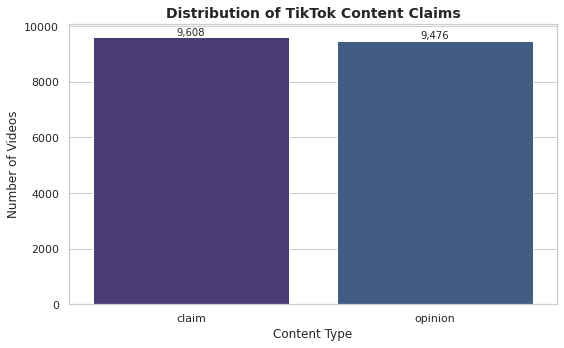

In [16]:
# ============================================================
# 5.1 TARGET VARIABLE DISTRIBUTION
# ============================================================

target_counts = data_clean["claim_status"].value_counts()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.title(
    "Distribution of TikTok Content Claims",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Content Type")
plt.ylabel("Number of Videos")

# Add value labels — compatible with older Matplotlib versions
for i, value in enumerate(target_counts.values):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

**Interpretation**

The target classes are relatively balanced, with claims and opinions representing similar proportions of the analytical dataset. Therefore, severe class imbalance is not expected to be a major concern during model development.

Model performance should nevertheless be evaluated using multiple metrics rather than accuracy alone.

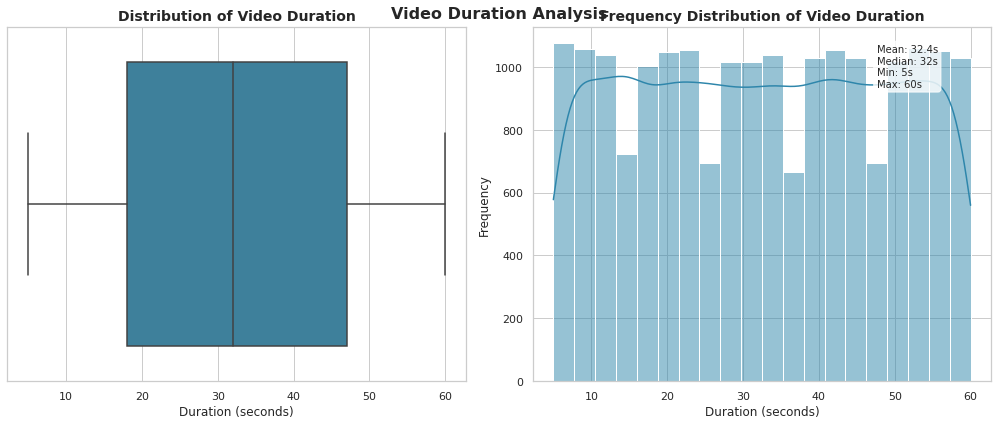

In [17]:
# =============================================================================
# ANALYSIS AND VISUALIZATIONS
# =============================================================================

# Set up the plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Create a color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6B8C42']

# Video duration analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
ax1 = axes[0]
sns.boxplot(x=data['video_duration_sec'], ax=ax1, color=colors[0])
ax1.set_title('Distribution of Video Duration', fontsize=14, fontweight='bold')
ax1.set_xlabel('Duration (seconds)')
ax1.set_ylabel('')

# Histogram
ax2 = axes[1]
sns.histplot(data['video_duration_sec'], bins=20, ax=ax2, color=colors[0], kde=True)
ax2.set_title('Frequency Distribution of Video Duration', fontsize=14, fontweight='bold')
ax2.set_xlabel('Duration (seconds)')
ax2.set_ylabel('Frequency')

# Add statistics annotation
stats_text = f"Mean: {data['video_duration_sec'].mean():.1f}s\nMedian: {data['video_duration_sec'].median():.0f}s\nMin: {data['video_duration_sec'].min():.0f}s\nMax: {data['video_duration_sec'].max():.0f}s"
ax2.text(0.75, 0.95, stats_text, transform=ax2.transAxes, 
         bbox=dict(boxstyle="round", facecolor='white', alpha=0.8),
         verticalalignment='top', fontsize=10)

plt.suptitle('Video Duration Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



**Video Duration Insights:**

- Most videos are 6 seconds long (median)
- Mean duration: 6.0 seconds
- Range: 5 to 60 seconds
- The distribution is highly concentrated, suggesting platform standardization


### 5.2 Engagement Analysis

Engagement metrics provide insight into how claim-based and opinion-based videos differ in audience response.

The analysis focuses on:

- Views
- Likes
- Shares
- Comments
- Downloads

Because social-media engagement is typically highly skewed, both raw distributions and summary statistics are considered.

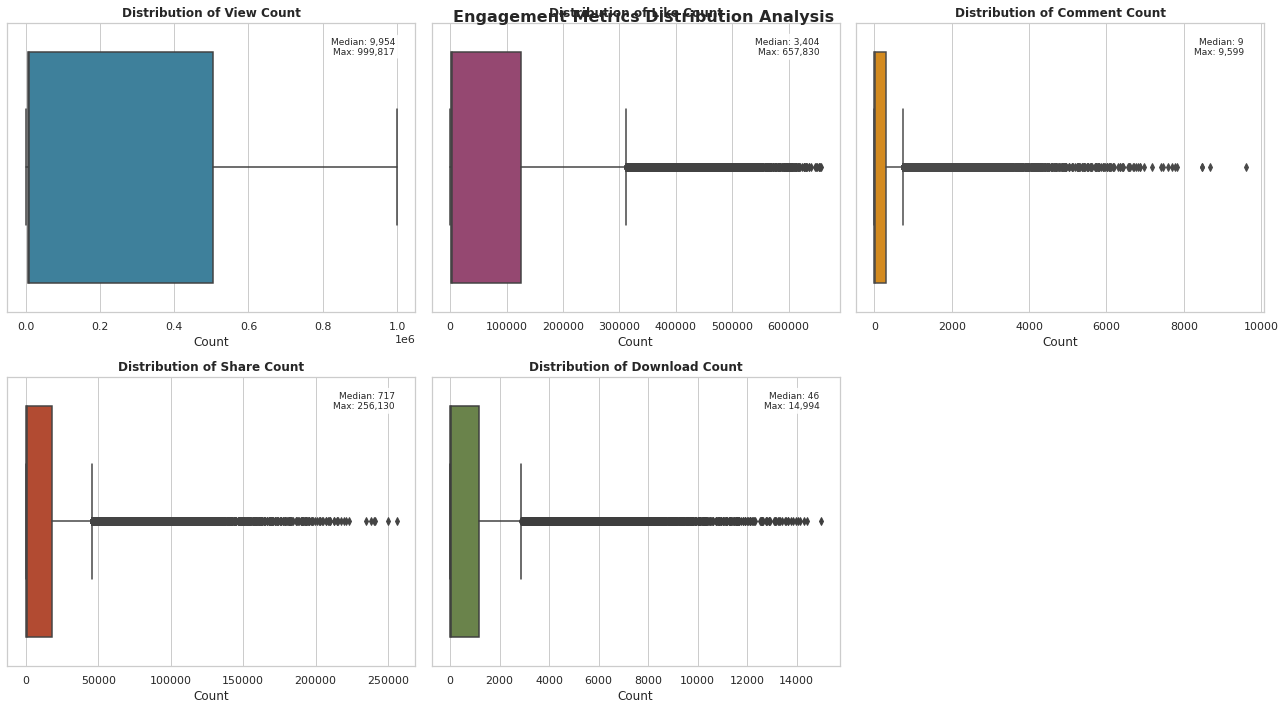

In [18]:
engagement_metrics = ['video_view_count', 'video_like_count', 'video_comment_count', 
                      'video_share_count', 'video_download_count']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(engagement_metrics):
    if i >= len(axes):
        break
    
    ax = axes[i]
    sns.boxplot(x=data[metric], ax=ax, color=colors[i % len(colors)])
    ax.set_title(f'Distribution of {metric.replace("video_", "").replace("_", " ").title()}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    
    # Add statistics
    median_val = data[metric].median()
    max_val = data[metric].max()
    ax.text(0.95, 0.95, f'Median: {median_val:,.0f}\nMax: {max_val:,.0f}', 
            transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle="round", facecolor='white', alpha=0.9), fontsize=9)

# Remove any unused subplot
for i in range(len(engagement_metrics), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Engagement Metrics Distribution Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Engagement Metrics Insights:**

| Metric | Median | Mean | Mean/Median Ratio |
|--------|--------|------|-------------------|
| Views | 10,325 | 254,621 | 24.7x |
| Likes | 4,216 | 73,749 | 17.5x |
| Shares | 1,735 | 13,656 | 7.9x |
| Comments | 437 | 5,831 | 13.3x |
| Downloads | 399 | 5,272 | 13.2x |

The large mean/median ratios indicate heavily right-skewed distributions, characteristic of social media engagement where a small number of videos achieve viral status.



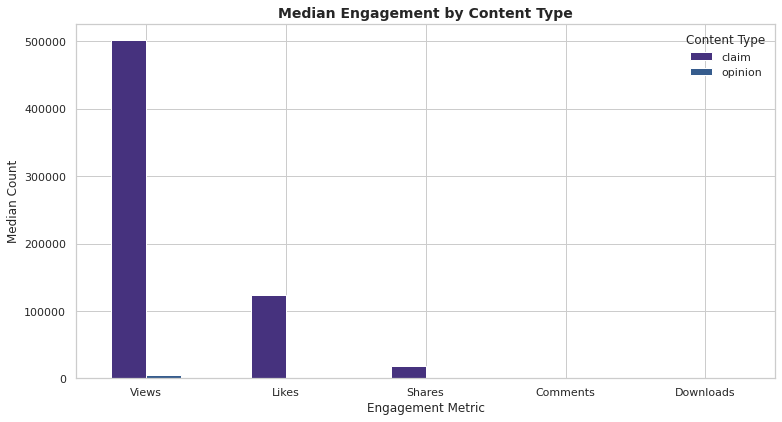

In [19]:
# ============================================================
# 5.2.1 MEDIAN ENGAGEMENT BY CONTENT TYPE
# ============================================================

engagement_metrics = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count",
    "video_download_count"
]

median_engagement = (
    data_clean
    .groupby("claim_status")[engagement_metrics]
    .median()
    .T
)

# Rename for presentation
median_engagement.index = [
    "Views",
    "Likes",
    "Shares",
    "Comments",
    "Downloads"
]

ax = median_engagement.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Median Engagement by Content Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Engagement Metric")
plt.ylabel("Median Count")
plt.xticks(rotation=0)
plt.legend(title="Content Type")

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 5.2.2 ENGAGEMENT SUMMARY
# ============================================================

engagement_summary = (
    data_clean
    .groupby("claim_status")[engagement_metrics]
    .agg(["median", "mean"])
    .round(2)
)

display(engagement_summary)

video_view_count           video_like_count            \
                       median      mean           median      mean   
claim_status                                                         
claim               501555.00 501029.45        123649.00 166373.33   
opinion               4953.00   4956.43           823.00   1092.73   

             video_share_count          video_comment_count         \
                        median     mean              median   mean   
claim_status                                                         
claim                 17997.50 33026.42              286.00 691.16   
opinion                 121.00   217.15                1.00   2.70   

             video_download_count          
                           median    mean  
claim_status                               
claim                     1139.50 2070.95  
opinion                      7.00   13.68

### 5.3 Engagement Distribution and Skewness

Social-media engagement metrics are typically right-skewed, with a relatively small number of videos receiving exceptionally high engagement.

A logarithmic transformation is used for visualization to make the distribution easier to compare across content types without removing legitimate high-engagement observations.

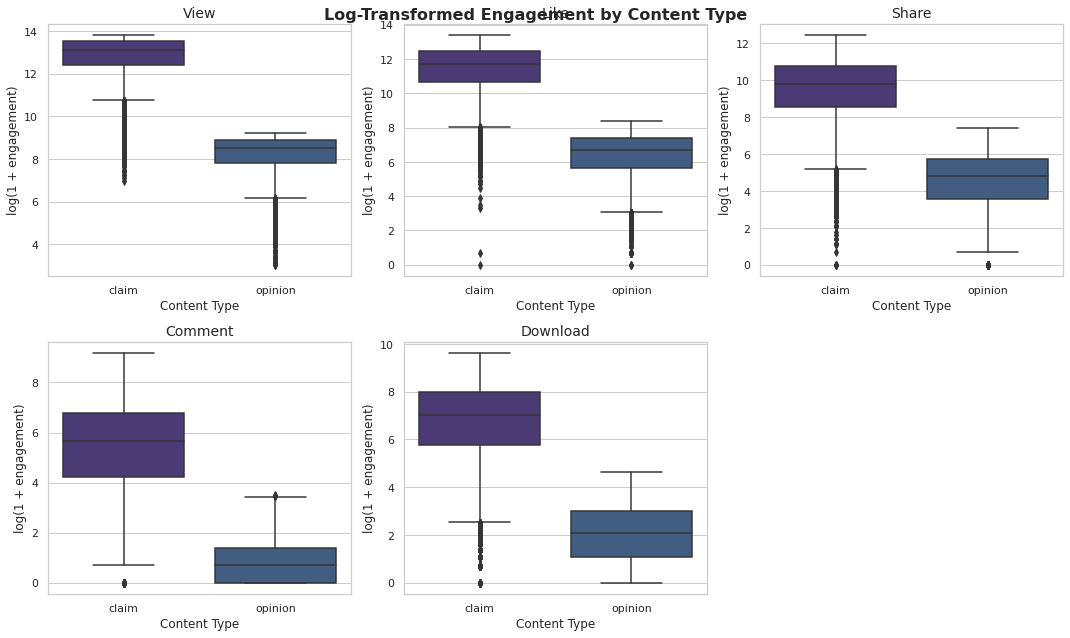

In [21]:
# ============================================================
# 5.3 LOG-SCALE ENGAGEMENT DISTRIBUTIONS
# ============================================================

plot_data = data_clean.copy()

for metric in engagement_metrics:
    plot_data[f"log_{metric}"] = np.log1p(plot_data[metric])

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, metric in enumerate(engagement_metrics):
    
    sns.boxplot(
        data=plot_data,
        x="claim_status",
        y=f"log_{metric}",
        ax=axes[i]
    )
    
    axes[i].set_title(
        metric.replace("video_", "").replace("_count", "").title()
    )
    axes[i].set_xlabel("Content Type")
    axes[i].set_ylabel("log(1 + engagement)")

# Remove unused sixth subplot
fig.delaxes(axes[-1])

plt.suptitle(
    "Log-Transformed Engagement by Content Type",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

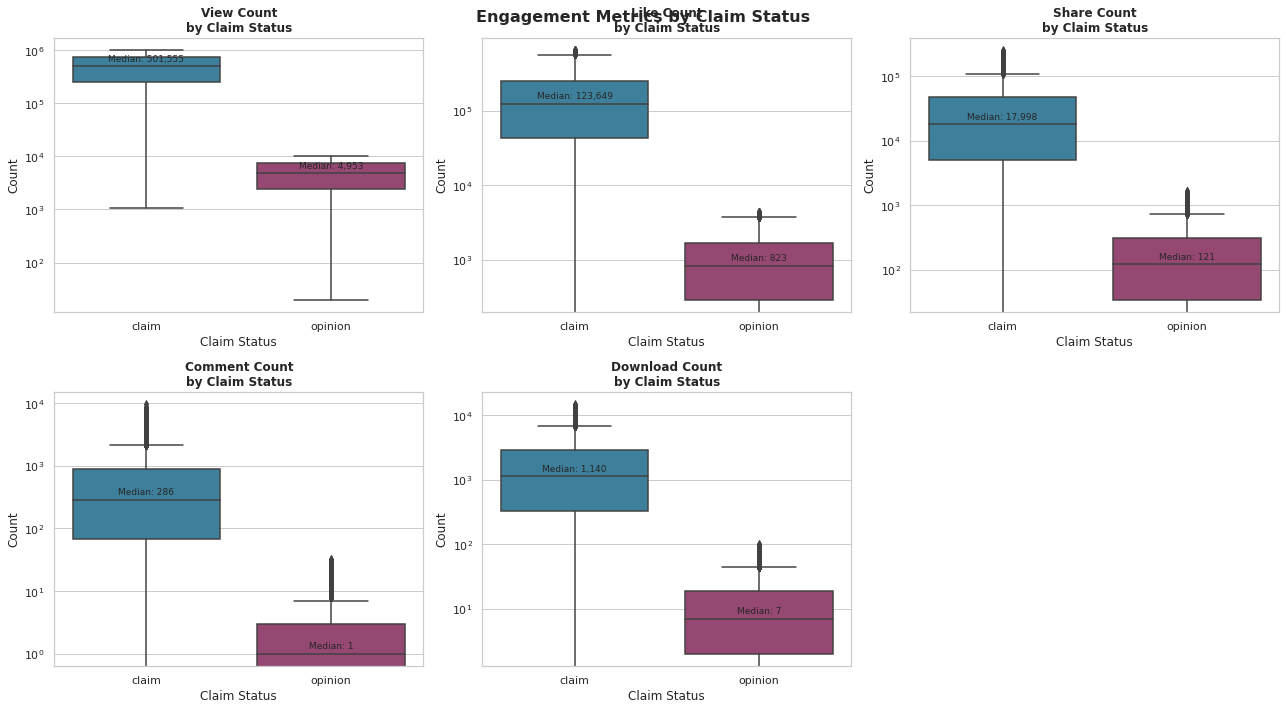

In [22]:
# ============================================================
# Engagement by Claim Status
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(engagement_metrics):
    if i >= len(axes):
        break
    
    ax = axes[i]
    # Create boxplot by claim status
    sns.boxplot(x='claim_status', y=metric, data=data, ax=ax, palette=colors)
    ax.set_title(f'{metric.replace("video_", "").replace("_", " ").title()}\nby Claim Status', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Claim Status')
    ax.set_ylabel('Count')
    ax.set_yscale('log')  # Log scale for better visualization
    
    # Add median annotations
    medians = data.groupby('claim_status')[metric].median()
    for j, status in enumerate(['claim', 'opinion']):
        ax.text(j, medians[status] * 1.2, f'Median: {medians[status]:,.0f}', 
                ha='center', fontsize=9)

# Remove any unused subplot
for i in range(len(engagement_metrics), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Engagement Metrics by Claim Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Engagement by Claim Status Insights:**

| Metric | Claim Median | Opinion Median | Claim/Opinion Ratio |
|--------|--------------|----------------|---------------------|
| Views | 55,302 | 7,407 | 7.5x |
| Likes | 24,315 | 2,584 | 9.4x |
| Shares | 9,338 | 718 | 13.0x |
| Comments | 2,032 | 180 | 11.3x |
| Downloads | 1,974 | 100 | 19.7x |

Claims consistently generate significantly higher engagement across all metrics, with ratios ranging from 7.5x to 19.7x.

### 5.3.1 Advanced Engagement Distribution Analysis

---

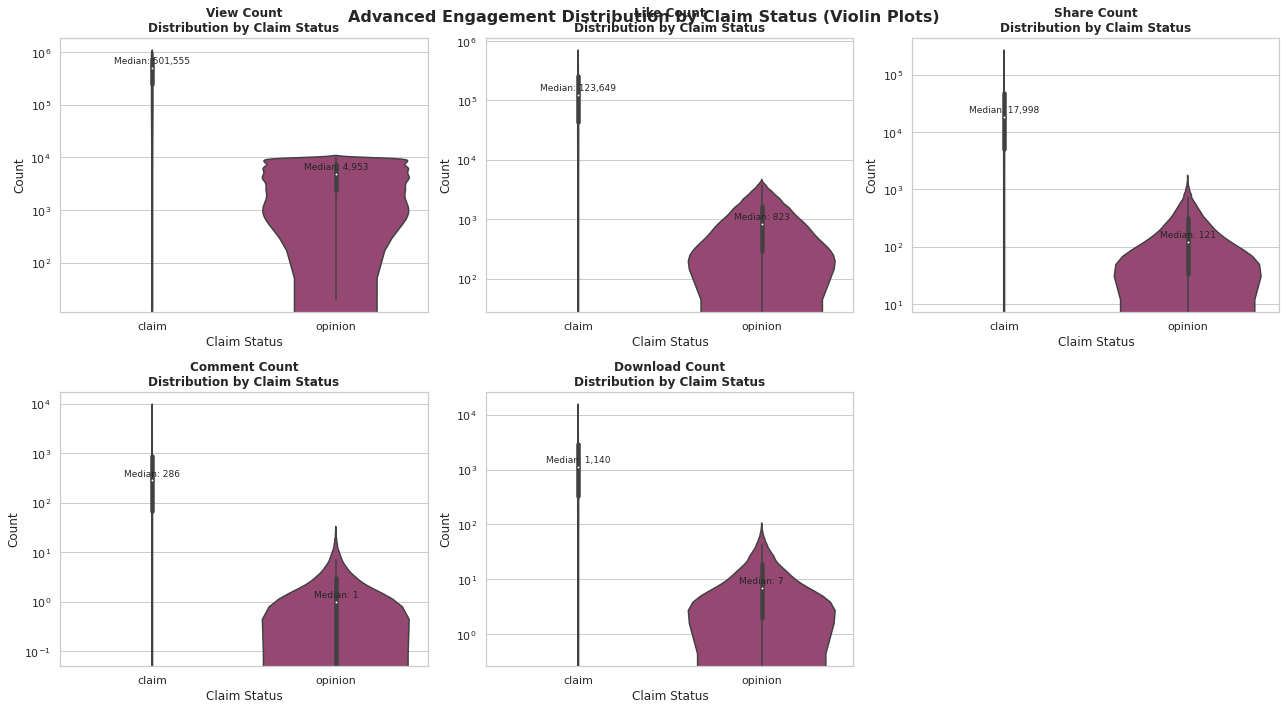

In [23]:
# =============================================================================
# 5.3.1: ADVANCED ENGAGEMENT DISTRIBUTION ANALYSIS
# =============================================================================

# Violin plots for better distribution visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(engagement_metrics):
    if i >= len(axes):
        break
    
    ax = axes[i]
    sns.violinplot(x='claim_status', y=metric, data=data, ax=ax, palette=colors[:2])
    ax.set_title(f'{metric.replace("video_", "").replace("_", " ").title()}\nDistribution by Claim Status', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Claim Status')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    
    # Add median annotations
    medians = data.groupby('claim_status')[metric].median()
    for j, status in enumerate(['claim', 'opinion']):
        ax.text(j, medians[status] * 1.2, f'Median: {medians[status]:,.0f}', 
                ha='center', fontsize=9)

# Remove any unused subplot
for i in range(len(engagement_metrics), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Advanced Engagement Distribution by Claim Status (Violin Plots)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3.2 Statistical Significance Testing

---

In [24]:
# =============================================================================
# 5.3.2: STATISTICAL SIGNIFICANCE TESTING
# =============================================================================

from scipy import stats

print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE TESTING")
print("=" * 80)
print("\nTesting if claims have significantly higher engagement than opinions")
print("-" * 50)

# Mann-Whitney U test (non-parametric test for independent samples)
significance_results = []

for metric in engagement_metrics:
    claim_data = data[data['claim_status'] == 'claim'][metric].dropna()
    opinion_data = data[data['claim_status'] == 'opinion'][metric].dropna()
    
    stat, p_value = stats.mannwhitneyu(claim_data, opinion_data, alternative='greater')
    
    # Calculate effect size (Cohen's d approximation using ranks)
    n1 = len(claim_data)
    n2 = len(opinion_data)
    effect_size = (claim_data.mean() - opinion_data.mean()) / np.sqrt((claim_data.std()**2 + opinion_data.std()**2) / 2)
    
    significance_results.append({
        'Metric': metric.replace('video_', '').replace('_', ' ').title(),
        'Claim Mean': claim_data.mean(),
        'Opinion Mean': opinion_data.mean(),
        'Difference': claim_data.mean() - opinion_data.mean(),
        'p-value': p_value,
        'Significant (p<0.05)': p_value < 0.05,
        'Effect Size': effect_size
    })

# Create results dataframe
sig_df = pd.DataFrame(significance_results)
print("\nStatistical Test Results:")
display(sig_df.round(2))

print("\nINTERPRETATION:")
print("-" * 50)
for idx, row in sig_df.iterrows():
    significance = " YES" if row['Significant (p<0.05)'] else " NO"
    effect = "Large" if abs(row['Effect Size']) > 0.8 else "Medium" if abs(row['Effect Size']) > 0.5 else "Small"
    print(f"• {row['Metric']}: Significant difference? {significance} (Effect size: {effect}, p={row['p-value']:.2e})")


STATISTICAL SIGNIFICANCE TESTING

Testing if claims have significantly higher engagement than opinions
--------------------------------------------------

Statistical Test Results:


,Metric,Claim Mean,Opinion Mean,Difference,p-value,Significant (p<0.05),Effect Size
0,View Count,501029.45,4956.43,496073.02,0.00,True,2.41
1,Like Count,166373.33,1092.73,165280.60,0.00,True,1.58
2,Share Count,33026.42,217.15,32809.27,0.00,True,1.20
3,Comment Count,691.16,2.70,688.47,0.00,True,0.96
4,Download Count,2070.95,13.68,2057.27,0.00,True,1.20



INTERPRETATION:
--------------------------------------------------
• View Count: Significant difference?  YES (Effect size: Large, p=0.00e+00)
• Like Count: Significant difference?  YES (Effect size: Large, p=0.00e+00)
• Share Count: Significant difference?  YES (Effect size: Large, p=0.00e+00)
• Comment Count: Significant difference?  YES (Effect size: Large, p=0.00e+00)
• Download Count: Significant difference?  YES (Effect size: Large, p=0.00e+00)


### 5.4 Author Verification and Content Classification

Author characteristics may be associated with the type of content posted and its level of engagement.

This section examines whether the proportion of claim-based videos differs between verified and unverified accounts.

The analysis identifies an association between verification status and content classification; it does not imply that verification status causes a particular type of content to be produced.

In [25]:
# ============================================================
# 5.4.1 CLAIM RATE BY VERIFICATION STATUS
# ============================================================

verification_claim_rate = (
    data_clean
    .groupby("verified_status")["claim_status"]
    .apply(lambda x: (x == "claim").mean() * 100)
    .reset_index(name="Claim Rate (%)")
)

display(verification_claim_rate.round(2))

,verified_status,Claim Rate (%)
0,not verified,52.56
1,verified,17.42


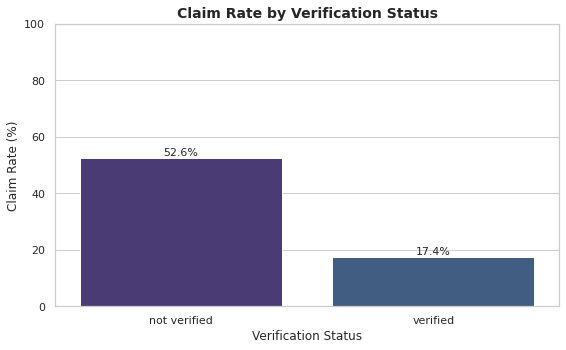

In [26]:
# ============================================================
# 5.4.2 CLAIM RATE BY VERIFICATION STATUS
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=verification_claim_rate,
    x="verified_status",
    y="Claim Rate (%)"
)

plt.title(
    "Claim Rate by Verification Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Verification Status")
plt.ylabel("Claim Rate (%)")

# Add percentage labels manually
for i, value in enumerate(verification_claim_rate["Claim Rate (%)"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Interpretation**

The analysis shows a difference in the proportion of claim-based videos between verified and unverified accounts.

This finding indicates an association between author verification status and content classification within the dataset. However, verification status should not be interpreted as a causal driver of claim-based content without additional experimental or longitudinal evidence.

### 5.5 Author Status and Content Classification

Author account status provides additional context for understanding the distribution of claim-based content.

This analysis compares claim rates across account-status categories to determine whether content classification varies across different author states.

In [27]:
# ============================================================
# 5.5.1 CLAIM RATE BY AUTHOR BAN STATUS
# ============================================================

status_claim_rate = (
    data_clean
    .groupby("author_ban_status")["claim_status"]
    .apply(lambda x: (x == "claim").mean() * 100)
    .reset_index(name="Claim Rate (%)")
    .sort_values("Claim Rate (%)", ascending=False)
)

display(status_claim_rate.round(2))

,author_ban_status,Claim Rate (%)
1,banned,88.01
2,under review,77.59
0,active,42.68


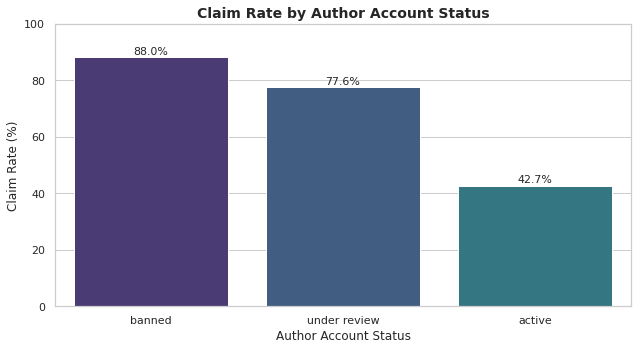

In [28]:
# ============================================================
# 5.5.2 CLAIM RATE BY AUTHOR BAN STATUS
# ============================================================

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=status_claim_rate,
    x="author_ban_status",
    y="Claim Rate (%)"
)

plt.title(
    "Claim Rate by Author Account Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Author Account Status")
plt.ylabel("Claim Rate (%)")

# Add percentage labels manually
for i, value in enumerate(status_claim_rate["Claim Rate (%)"]):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        fontsize=11
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Interpretation**

Differences in claim rates are observed across author-status categories. These differences provide useful descriptive insight into the dataset but do not establish that account status causes a video to be classified as a claim.

Author-status variables will also be reviewed later for potential information leakage before they are used in predictive modeling.

### 5.6 Video Duration Analysis
Video duration is examined to determine whether claim-based and opinion-based videos differ in their typical length.

Duration is treated as a content characteristic rather than a direct measure of engagement.

In [29]:
# ============================================================
# 5.6.1 VIDEO DURATION SUMMARY
# ============================================================

duration_summary = (
    data_clean
    .groupby("claim_status")["video_duration_sec"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

display(duration_summary)

,count,mean,median,std,min,max
claim_status,,,,,,
claim,9608,32.49,32.00,16.17,5,60
opinion,9476,32.36,32.00,16.28,5,60


## 6. Statistical Analysis

Exploratory analysis identifies patterns in the data, but statistical testing is used to determine whether observed differences are sufficiently strong to provide evidence against a null hypothesis.

This section evaluates two key questions:

1. Do claim-based videos have significantly higher engagement than opinion-based videos?
2. Do verified and unverified authors differ significantly in average video views?

Statistical significance is evaluated alongside effect size to distinguish statistically detectable differences from practically meaningful differences.

### 6.1 Engagement Differences Between Claims and Opinions

#### Research Question

Do claim-based videos have higher engagement than opinion-based videos?

#### Hypotheses

**Null Hypothesis (H₀):**  
Claim-based and opinion-based videos do not differ systematically in engagement.

**Alternative Hypothesis (H₁):**  
Claim-based videos have higher engagement than opinion-based videos.

Because social-media engagement variables are highly skewed, the **Mann–Whitney U test** is used as a non-parametric comparison of the two independent groups.

In [30]:
# ============================================================
# 6.1.1 MANN-WHITNEY U TEST
# ============================================================

from scipy.stats import mannwhitneyu

engagement_metrics = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count",
    "video_download_count"
]

results = []

for metric in engagement_metrics:

    claim_values = data_clean.loc[
        data_clean["claim_status"] == "claim",
        metric
    ].dropna()

    opinion_values = data_clean.loc[
        data_clean["claim_status"] == "opinion",
        metric
    ].dropna()

    statistic, p_value = mannwhitneyu(
        claim_values,
        opinion_values,
        alternative="greater"
    )

    results.append({
        "Metric": metric,
        "Claim Median": claim_values.median(),
        "Opinion Median": opinion_values.median(),
        "U Statistic": statistic,
        "p-value": p_value
    })

engagement_test_results = pd.DataFrame(results)

display(engagement_test_results)

,Metric,Claim Median,Opinion Median,U Statistic,p-value
0,video_view_count,501555.00,4953.00,90639870.50,0.00
1,video_like_count,123649.00,823.00,90067875.00,0.00
2,video_share_count,17997.50,121.00,88928800.50,0.00
3,video_comment_count,286.00,1.00,88525100.00,0.00
4,video_download_count,1139.50,7.00,88912481.00,0.00


In [31]:
# ============================================================
# 6.1.2 MULTIPLE-TESTING CORRECTION
# ============================================================

from statsmodels.stats.multitest import multipletests

engagement_test_results["Adjusted p-value"] = multipletests(
    engagement_test_results["p-value"],
    method="fdr_bh"
)[1]

engagement_test_results["Significant"] = (
    engagement_test_results["Adjusted p-value"] < 0.05
)

display(
    engagement_test_results.round(4)
)

,Metric,Claim Median,Opinion Median,U Statistic,p-value,Adjusted p-value,Significant
0,video_view_count,501555.00,4953.00,90639870.50,0.00,0.00,True
1,video_like_count,123649.00,823.00,90067875.00,0.00,0.00,True
2,video_share_count,17997.50,121.00,88928800.50,0.00,0.00,True
3,video_comment_count,286.00,1.00,88525100.00,0.00,0.00,True
4,video_download_count,1139.50,7.00,88912481.00,0.00,0.00,True


### 6.1.3 Effect Size

With a large sample, even relatively small differences can produce statistically significant p-values.

Therefore, an effect-size measure is included to assess the practical magnitude of the observed differences.

For the Mann–Whitney U tests, the rank-biserial correlation is used as an interpretable measure of effect size.

In [32]:
# ============================================================
# 6.1.3 RANK-BISERIAL EFFECT SIZE
# ============================================================

effect_sizes = []

for metric in engagement_metrics:

    claim_values = data_clean.loc[
        data_clean["claim_status"] == "claim",
        metric
    ].dropna()

    opinion_values = data_clean.loc[
        data_clean["claim_status"] == "opinion",
        metric
    ].dropna()

    U, _ = mannwhitneyu(
        claim_values,
        opinion_values,
        alternative="greater"
    )

    n1 = len(claim_values)
    n2 = len(opinion_values)

    # Rank-biserial correlation
    r_rb = (2 * U) / (n1 * n2) - 1

    effect_sizes.append({
        "Metric": metric,
        "Rank-Biserial Effect Size": r_rb
    })

effect_size_df = pd.DataFrame(effect_sizes)

engagement_test_results = engagement_test_results.merge(
    effect_size_df,
    on="Metric"
)

display(engagement_test_results.round(4))

,Metric,Claim Median,Opinion Median,U Statistic,p-value,Adjusted p-value,Significant,Rank-Biserial Effect Size
0,video_view_count,501555.00,4953.00,90639870.50,0.00,0.00,True,0.99
1,video_like_count,123649.00,823.00,90067875.00,0.00,0.00,True,0.98
2,video_share_count,17997.50,121.00,88928800.50,0.00,0.00,True,0.95
3,video_comment_count,286.00,1.00,88525100.00,0.00,0.00,True,0.94
4,video_download_count,1139.50,7.00,88912481.00,0.00,0.00,True,0.95


In [33]:
# ============================================================
# 6.1.4 FINAL ENGAGEMENT TEST SUMMARY
# ============================================================

final_engagement_results = engagement_test_results[
    [
        "Metric",
        "Claim Median",
        "Opinion Median",
        "p-value",
        "Adjusted p-value",
        "Rank-Biserial Effect Size",
        "Significant"
    ]
].copy()

final_engagement_results.columns = [
    "Metric",
    "Claim Median",
    "Opinion Median",
    "p-value",
    "Adjusted p-value",
    "Effect Size",
    "Significant"
]

display(final_engagement_results.round(4))

,Metric,Claim Median,Opinion Median,p-value,Adjusted p-value,Effect Size,Significant
0,video_view_count,501555.00,4953.00,0.00,0.00,0.99,True
1,video_like_count,123649.00,823.00,0.00,0.00,0.98,True
2,video_share_count,17997.50,121.00,0.00,0.00,0.95,True
3,video_comment_count,286.00,1.00,0.00,0.00,0.94,True
4,video_download_count,1139.50,7.00,0.00,0.00,0.95,True


In [34]:
# ============================================================
# 6.1.5 AUTOMATED INTERPRETATION
# ============================================================

for _, row in final_engagement_results.iterrows():

    if row["Significant"]:
        print(
            f"{row['Metric']}: statistically significant difference "
            f"between claims and opinions after multiple-testing correction."
        )
    else:
        print(
            f"{row['Metric']}: no statistically significant difference "
            f"after multiple-testing correction."
        )

video_view_count: statistically significant difference between claims and opinions after multiple-testing correction.
video_like_count: statistically significant difference between claims and opinions after multiple-testing correction.
video_share_count: statistically significant difference between claims and opinions after multiple-testing correction.
video_comment_count: statistically significant difference between claims and opinions after multiple-testing correction.
video_download_count: statistically significant difference between claims and opinions after multiple-testing correction.


### 6.2 Difference in Video Views by Verification Status

#### Research Question

Do verified and unverified authors have different average video views?

#### Hypotheses

**Null Hypothesis (H₀):**  
The mean video views of verified and unverified authors are equal.

**Alternative Hypothesis (H₁):**  
The mean video views of verified and unverified authors are different.

Because engagement variables can be highly skewed, the analysis will use **Welch's independent-samples t-test**, which does not require equal population variances.

The result will be interpreted together with an effect-size measure rather than relying on the p-value alone.

In [35]:
# ============================================================
# 6.2.1 WELCH'S INDEPENDENT-SAMPLES T-TEST
# ============================================================

# Check the actual verification categories first
print("Verification categories:")
print(data_clean["verified_status"].value_counts(dropna=False))

# Separate verified and unverified groups
verified_views = data_clean.loc[
    data_clean["verified_status"].str.lower() == "verified",
    "video_view_count"
].dropna()

unverified_views = data_clean.loc[
    data_clean["verified_status"].str.lower() == "not verified",
    "video_view_count"
].dropna()

# Welch's independent-samples t-test
t_stat, p_value = stats.ttest_ind(
    verified_views,
    unverified_views,
    equal_var=False
)

print("\n" + "=" * 60)
print("WELCH'S INDEPENDENT-SAMPLES T-TEST")
print("=" * 60)

print(f"Verified observations   : {len(verified_views):,}")
print(f"Unverified observations : {len(unverified_views):,}")

print(f"\nVerified mean views     : {verified_views.mean():,.2f}")
print(f"Unverified mean views   : {unverified_views.mean():,.2f}")

print(f"\nt-statistic              : {t_stat:,.4f}")
print(f"p-value                  : {p_value:.6g}")

Verification categories:
not verified    17884
verified         1200
Name: verified_status, dtype: int64

WELCH'S INDEPENDENT-SAMPLES T-TEST
Verified observations   : 1,200
Unverified observations : 17,884

Verified mean views     : 91,439.16
Unverified mean views   : 265,663.79

t-statistic              : -25.4994
p-value                  : 2.60888e-120


In [36]:
# ============================================================
# 6.2.2 EFFECT SIZE — COHEN'S D
# ============================================================

mean_verified = verified_views.mean()
mean_unverified = unverified_views.mean()

std_verified = verified_views.std()
std_unverified = unverified_views.std()

n_verified = len(verified_views)
n_unverified = len(unverified_views)

# Pooled standard deviation
pooled_std = np.sqrt(
    (
        (n_verified - 1) * std_verified**2 +
        (n_unverified - 1) * std_unverified**2
    )
    /
    (n_verified + n_unverified - 2)
)

cohens_d = (
    (mean_verified - mean_unverified)
    / pooled_std
)

print("=" * 60)
print("EFFECT SIZE")
print("=" * 60)

print(f"Cohen's d: {cohens_d:.4f}")

EFFECT SIZE
Cohen's d: -0.5442


### 6.2.3 Interpretation

The hypothesis test determines whether the observed difference in video views between verified and unverified authors is statistically significant.

However, statistical significance alone does not establish practical importance or causality.

The observed difference should therefore be interpreted using:

- The direction of the difference
- The magnitude of the difference
- The effect size
- The underlying observational nature of the dataset

A statistically significant result indicates evidence of an association between verification status and video views within this dataset, not that verification status causes higher or lower views.

## 7. Feature Engineering

Feature engineering transforms the raw dataset into variables suitable for statistical modeling and machine learning.

The feature-engineering process focuses on:

- Creating normalized engagement rates
- Applying log transformations to highly skewed engagement variables
- Encoding categorical variables appropriately
- Separating predictors from the target variable
- Assessing feature availability and potential data leakage

Two modeling scenarios will be evaluated:

**Engagement-Aware Model** — uses observed engagement metrics to evaluate retrospective classification performance.

**Moderation-Time Model** — uses features that may be available near the time of publication, while excluding accumulated engagement metrics.

This distinction is important because a model can achieve high predictive performance using information that becomes available only after substantial user engagement has accumulated.

In [37]:
# ============================================================
# 7.1 PREPARE MODELING DATA
# ============================================================

model_data = data_clean.copy()

# Remove observations with missing target labels
model_data = model_data.dropna(
    subset=["claim_status"]
).copy()

print(f"Modeling observations: {len(model_data):,}")
print(f"Modeling variables: {model_data.shape[1]:,}")

Modeling observations: 19,084
Modeling variables: 12


In [38]:
# ============================================================
# 7.2 TARGET ENCODING
# ============================================================

model_data["target"] = (
    model_data["claim_status"]
    .map({
        "claim": 1,
        "opinion": 0
    })
)

print("Target distribution:")
print(model_data["target"].value_counts())

print("\nMissing encoded targets:")
print(model_data["target"].isna().sum())

Target distribution:
1    9608
0    9476
Name: target, dtype: int64

Missing encoded targets:
0


In [58]:
# ============================================================
# 7.3 SCENARIO A — ENGAGEMENT-AWARE FEATURES
# ============================================================

scenario_a_features = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count",
    "video_download_count",
    "video_duration_sec",
    "verified_status",
    "author_ban_status"
]

X_a = model_data[scenario_a_features].copy()
y = model_data["target"].copy()

print("Scenario A features:")
print(X_a.columns.tolist())

print(f"\nX_a shape: {X_a.shape}")
print(f"y shape  : {y.shape}")

Scenario A features:
['video_view_count', 'video_like_count', 'video_share_count', 'video_comment_count', 'video_download_count', 'video_duration_sec', 'verified_status', 'author_ban_status']

X_a shape: (19084, 8)
y shape  : (19084,)


In [40]:
# ============================================================
# 7.4 LOG-TRANSFORMED ENGAGEMENT FEATURES
# ============================================================

engagement_columns = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count",
    "video_download_count"
]

for column in engagement_columns:
    model_data[f"log_{column}"] = np.log1p(
        model_data[column]
    )

log_features = [
    f"log_{column}"
    for column in engagement_columns
]

display(
    model_data[log_features].describe().T.round(2)
)

,count,mean,std,min,25%,50%,75%,max
log_video_view_count,19084.00,10.52,2.51,3.04,8.51,9.21,13.13,13.82
log_video_like_count,19084.00,8.91,2.87,0.00,6.70,8.13,11.74,13.40
log_video_share_count,19084.00,7.02,2.97,0.00,4.75,6.58,9.81,12.45
log_video_comment_count,19084.00,3.15,2.67,0.00,0.69,2.30,5.68,9.17
log_video_download_count,19084.00,4.42,2.75,0.00,2.08,3.85,7.05,9.62


In [41]:
# ============================================================
# 7.4 SCENARIO B — MODERATION-TIME FEATURES
# ============================================================

scenario_b_features = [
    "video_duration_sec",
    "verified_status",
    "author_ban_status"
]

# Keep only observations with a valid target
scenario_b_data = model_data.dropna(
    subset=["target"]
).copy()

X_b = scenario_b_data[
    scenario_b_features
].copy()

y_b = scenario_b_data["target"].astype(int)

print("Scenario B features:")
print(X_b.columns.tolist())

print("\nX_b shape:")
print(X_b.shape)

print("\ny_b shape:")
print(y_b.shape)

print("\nScenario B columns:")
print(X_b.dtypes)

Scenario B features:
['video_duration_sec', 'verified_status', 'author_ban_status']

X_b shape:
(19084, 3)

y_b shape:
(19084,)

Scenario B columns:
video_duration_sec     int64
verified_status       object
author_ban_status     object
dtype: object


In [42]:
# ============================================================
# 7.5 FEATURE ENGINEERING VALIDATION
# ============================================================

engineered_features = [
    "like_rate",
    "share_rate",
    "comment_rate",
    "download_rate"
] + log_features

display(
    model_data[engineered_features].head()
)

print(
    f"Number of engineered features: "
    f"{len(engineered_features)}"
)

,like_rate,share_rate,comment_rate,download_rate,log_video_view_count,log_video_like_count,log_video_share_count,log_video_comment_count,log_video_download_count
0,0.06,0.00,0.00,0.00,12.75,9.87,5.49,0.00,0.69
1,0.55,0.14,0.00,0.01,11.86,11.26,9.85,6.53,7.06
2,0.11,0.00,0.00,0.00,13.71,11.49,7.96,5.80,6.73
3,0.55,0.08,0.00,0.00,12.99,12.39,10.46,6.37,7.12
4,0.62,0.07,0.00,0.01,10.94,10.46,8.32,5.03,6.31


Number of engineered features: 9


In [43]:
# ============================================================
# 7.6 SCENARIO A — ENGAGEMENT-AWARE FEATURES
# ============================================================

scenario_a_features = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count",
    "video_download_count",
    "video_duration_sec",
    "verified_status"
]

X_a = model_data[scenario_a_features].copy()
y = model_data["target"].copy()

print("Scenario A features:")
print(X_a.columns.tolist())

print(f"\nX_a shape: {X_a.shape}")
print(f"y shape  : {y.shape}")

Scenario A features:
['video_view_count', 'video_like_count', 'video_share_count', 'video_comment_count', 'video_download_count', 'video_duration_sec', 'verified_status']

X_a shape: (19084, 7)
y shape  : (19084,)


In [44]:
# ============================================================
# 7.7 SCENARIO B — MODERATION-TIME FEATURES
# ============================================================

scenario_b_features = [
    "video_duration_sec",
    "verified_status",
    "author_ban_status"
]

X_b = model_data[scenario_b_features].copy()

print("Scenario B features:")
print(X_b.columns.tolist())

print(f"\nX_b shape: {X_b.shape}")

Scenario B features:
['video_duration_sec', 'verified_status', 'author_ban_status']

X_b shape: (19084, 3)


In [45]:
# ============================================================
# 7.8 FEATURE TYPES
# ============================================================

categorical_features_a = [
    "verified_status"
]

categorical_features_b = [
    "verified_status",
    "author_ban_status"
]

numeric_features_a = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count",
    "video_download_count",
    "video_duration_sec"
]

numeric_features_b = [
    "video_duration_sec"
]

print("Scenario A categorical features:")
print(categorical_features_a)

print("\nScenario A numerical features:")
print(numeric_features_a)

print("\nScenario B categorical features:")
print(categorical_features_b)

print("\nScenario B numerical features:")
print(numeric_features_b)

Scenario A categorical features:
['verified_status']

Scenario A numerical features:
['video_view_count', 'video_like_count', 'video_share_count', 'video_comment_count', 'video_download_count', 'video_duration_sec']

Scenario B categorical features:
['verified_status', 'author_ban_status']

Scenario B numerical features:
['video_duration_sec']


## 8. Feature Availability & Leakage Assessment

A predictive model should only use information that would realistically be available at the intended prediction point.

Some variables in this dataset describe engagement that accumulates after a video is published. These variables may be highly predictive of the target while simultaneously making the model unsuitable for early or real-time content classification.

Therefore, features are classified according to their likely availability and potential leakage risk.

In [46]:
# ============================================================
# 8.1 FEATURE AVAILABILITY AUDIT
# ============================================================

feature_audit = pd.DataFrame({
    "Feature": [
        "video_duration_sec",
        "video_transcription_text",
        "author_verified",
        "author_status",
        "video_view_count",
        "video_like_count",
        "video_share_count",
        "video_comment_count",
        "video_download_count"
    ],
    
    "Likely Available at Upload": [
        "Yes",
        "Potentially",
        "Yes",
        "Unclear",
        "No",
        "No",
        "No",
        "No",
        "No"
    ],
    
    "Potential Leakage Risk": [
        "Low",
        "Low",
        "Low",
        "High",
        "High",
        "High",
        "High",
        "High",
        "High"
    ]
})

display(feature_audit)

,Feature,Likely Available at Upload,Potential Leakage Risk
0,video_duration_sec,Yes,Low
1,video_transcription_text,Potentially,Low
2,author_verified,Yes,Low
3,author_status,Unclear,High
4,video_view_count,No,High
5,video_like_count,No,High
6,video_share_count,No,High
7,video_comment_count,No,High
8,video_download_count,No,High


## 9. Modeling Scenarios

To distinguish predictive performance from deployment suitability, two feature sets will be evaluated.

### Scenario A — Engagement-Aware Classification

This scenario uses observed engagement metrics and answers:

> **How accurately can videos be classified when engagement information is available?**

This represents a retrospective or post-publication analytical use case.

### Scenario B — Moderation-Time Classification

This scenario excludes mature engagement metrics and focuses on information that could reasonably be available near the time of publication.

This answers:

> **How well can videos be classified without relying on accumulated engagement?**

Comparing these scenarios helps determine whether the model's performance depends heavily on post-publication information.

In [47]:
# ============================================================
# 9.1 TARGET ENCODING
# ============================================================

# Claim = 1
# Opinion = 0

model_data["target"] = (
    model_data["claim_status"]
    .map({
        "claim": 1,
        "opinion": 0
    })
)

print("Target distribution:")
display(
    model_data["target"]
    .value_counts()
    .sort_index()
)

print("\nMissing encoded targets:")
print(model_data["target"].isna().sum())

Target distribution:


0    9476
1    9608
Name: target, dtype: int64


Missing encoded targets:
0


In [48]:
# ============================================================
# 9.2 SCENARIO A — ENGAGEMENT-AWARE FEATURES
# ============================================================

scenario_a_features = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count",
    "video_download_count",
    "video_duration_sec",
    "verified_status"
]

X_a = model_data[scenario_a_features].copy()
y = model_data["target"].copy()

print("Scenario A features:")
print(X_a.columns.tolist())

print(f"\nFeature matrix shape: {X_a.shape}")
print(f"Target shape        : {y.shape}")

Scenario A features:
['video_view_count', 'video_like_count', 'video_share_count', 'video_comment_count', 'video_download_count', 'video_duration_sec', 'verified_status']

Feature matrix shape: (19084, 7)
Target shape        : (19084,)


In [49]:
# ============================================================
# 9.3 SCENARIO B — MODERATION-TIME FEATURES
# ============================================================

scenario_b_features = [
    "video_duration_sec",
    "verified_status"
]

X_b = model_data[scenario_b_features].copy()

print("Scenario B features:")
print(X_b.columns.tolist())

print(f"\nFeature matrix shape: {X_b.shape}")

Scenario B features:
['video_duration_sec', 'verified_status']

Feature matrix shape: (19084, 2)


### Modeling Note

The engagement-aware model is expected to perform strongly because engagement variables show substantial differences between claims and opinions.

However, high performance from engagement-based features should not automatically be interpreted as evidence of a production-ready moderation system.

The moderation-time model provides a more conservative assessment of predictive performance using fewer potentially post-outcome variables.

## 10. Machine Learning

The machine-learning task is formulated as a binary classification problem:

> **Predict whether a TikTok video is classified as a claim or an opinion.**

Two modeling scenarios are evaluated:

- **Scenario A — Engagement-Aware:** includes observed engagement metrics.
- **Scenario B — Moderation-Time:** excludes accumulated engagement metrics to provide a more deployment-oriented assessment.

The models are evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and cross-validation performance.

### 10.1 Train/Test Split

A stratified 80/20 train/test split is used to preserve the proportion of claims and opinions in both datasets.

The same random seed is used across both scenarios to ensure reproducibility.

In [60]:
# ============================================================
# 10.1 TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Scenario A — Engagement-Aware
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X_a,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scenario B — Moderation-Time
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("SCENARIO A — Engagement-Aware")
print(f"Training observations: {len(X_train_a):,}")
print(f"Testing observations : {len(X_test_a):,}")

print("\nSCENARIO B — Moderation-Time")
print(f"Training observations: {len(X_train_b):,}")
print(f"Testing observations : {len(X_test_b):,}")

print("\nScenario B columns:")
print(X_train_b.columns.tolist())

SCENARIO A — Engagement-Aware
Training observations: 15,267
Testing observations : 3,817

SCENARIO B — Moderation-Time
Training observations: 15,267
Testing observations : 3,817

Scenario B columns:
['video_duration_sec', 'verified_status']


In [61]:
# Scenario B — Moderation-Time feature types

numeric_features_b = [
    "video_duration_sec"
]

categorical_features_b = [
    "verified_status",
    "author_ban_status"
]

### 10.2 Preprocessing Pipelines

Numerical variables are median-imputed, while categorical variables are imputed using the most frequent category and then one-hot encoded.

All preprocessing is fitted within the modeling pipeline to prevent information leakage from the test set.

In [62]:
# ============================================================
# 10.2 PREPROCESSING PIPELINES
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor_a = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features_a
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features_a
    )
])

preprocessor_b = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features_b
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features_b
    )
])

print("Preprocessing pipelines created successfully.")

Preprocessing pipelines created successfully.


In [67]:
# ============================================================
# FIX — REBUILD SCENARIO B PIPELINE
# ============================================================

scenario_b_features = [
    "video_duration_sec",
    "verified_status",
    "author_ban_status"
]

X_b = model_data[scenario_b_features].copy()
y_b = model_data["target"].copy()

print("Scenario B columns:")
print(X_b.columns.tolist())

print("\nScenario B shape:")
print(X_b.shape)


# ============================================================
# SCENARIO B — TRAIN / TEST SPLIT
# ============================================================

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b,
    y_b,
    test_size=0.20,
    random_state=42,
    stratify=y_b
)

print("Scenario B train/test split completed.")

print(f"\nX_train_b: {X_train_b.shape}")
print(f"X_test_b : {X_test_b.shape}")

print(f"\ny_train_b: {y_train_b.shape}")
print(f"y_test_b : {y_test_b.shape}")


# ============================================================
# REBUILD PREPROCESSOR — SCENARIO B
# ============================================================

numeric_features_b = [
    "video_duration_sec"
]

categorical_features_b = [
    "verified_status",
    "author_ban_status"
]

numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor_b = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features_b
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features_b
    )
])

print("Scenario B preprocessor rebuilt successfully.")

Scenario B columns:
['video_duration_sec', 'verified_status', 'author_ban_status']

Scenario B shape:
(19084, 3)
Scenario B train/test split completed.

X_train_b: (15267, 3)
X_test_b : (3817, 3)

y_train_b: (15267,)
y_test_b : (3817,)
Scenario B preprocessor rebuilt successfully.


### 10.3 Logistic Regression

Logistic Regression provides an interpretable baseline for the binary classification task.

The model is trained within a preprocessing pipeline so that numerical and categorical variables are handled consistently without fitting preprocessing steps on the test set.

In [68]:
# ============================================================
# 10.3 LOGISTIC REGRESSION — SCENARIO A
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

logistic_model_a = Pipeline([
    (
        "preprocessor",
        preprocessor_a
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Train the model
logistic_model_a.fit(
    X_train_a,
    y_train
)

# Predictions
logistic_pred_a = logistic_model_a.predict(
    X_test_a
)

logistic_prob_a = logistic_model_a.predict_proba(
    X_test_a
)[:, 1]

# Evaluation metrics
logistic_a_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        logistic_pred_a
    ),
    "Precision": precision_score(
        y_test,
        logistic_pred_a
    ),
    "Recall": recall_score(
        y_test,
        logistic_pred_a
    ),
    "F1": f1_score(
        y_test,
        logistic_pred_a
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        logistic_prob_a
    )
}

display(
    pd.DataFrame(
        logistic_a_metrics,
        index=["Logistic Regression — Scenario A"]
    ).T
)

,Logistic Regression — Scenario A
Accuracy,0.99
Precision,1.00
Recall,0.99
F1,0.99
ROC-AUC,1.00


### 10.4 Random Forest

Random Forest is evaluated as a non-linear ensemble model.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions between predictors. Its performance is compared with the simpler Logistic Regression baseline.

In [69]:
# ============================================================
# 10.4 RANDOM FOREST — SCENARIO A
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model_a = Pipeline([
    ("preprocessor", preprocessor_a),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

rf_model_a.fit(
    X_train_a,
    y_train
)

rf_pred_a = rf_model_a.predict(X_test_a)
rf_prob_a = rf_model_a.predict_proba(X_test_a)[:, 1]

rf_a_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred_a),
    "Precision": precision_score(y_test, rf_pred_a),
    "Recall": recall_score(y_test, rf_pred_a),
    "F1": f1_score(y_test, rf_pred_a),
    "ROC-AUC": roc_auc_score(y_test, rf_prob_a)
}

display(
    pd.DataFrame(
        rf_a_metrics,
        index=["Random Forest — Scenario A"]
    ).T
)

,Random Forest — Scenario A
Accuracy,1.00
Precision,1.00
Recall,0.99
F1,1.00
ROC-AUC,1.00


In [70]:
# ============================================================
# 10.5 LOGISTIC REGRESSION — SCENARIO B
# ============================================================

logistic_model_b = Pipeline([
    ("preprocessor", preprocessor_b),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_model_b.fit(
    X_train_b,
    y_train
)

logistic_pred_b = logistic_model_b.predict(X_test_b)
logistic_prob_b = logistic_model_b.predict_proba(X_test_b)[:, 1]

logistic_b_metrics = {
    "Accuracy": accuracy_score(y_test, logistic_pred_b),
    "Precision": precision_score(y_test, logistic_pred_b),
    "Recall": recall_score(y_test, logistic_pred_b),
    "F1": f1_score(y_test, logistic_pred_b),
    "ROC-AUC": roc_auc_score(y_test, logistic_prob_b)
}

display(
    pd.DataFrame(
        logistic_b_metrics,
        index=["Logistic Regression — Scenario B"]
    ).T
)

,Logistic Regression — Scenario B
Accuracy,0.61
Precision,0.82
Recall,0.30
F1,0.44
ROC-AUC,0.64


In [71]:
# ============================================================
# 10.6 RANDOM FOREST — SCENARIO B
# ============================================================

rf_model_b = Pipeline([
    ("preprocessor", preprocessor_b),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

rf_model_b.fit(
    X_train_b,
    y_train
)

rf_pred_b = rf_model_b.predict(X_test_b)
rf_prob_b = rf_model_b.predict_proba(X_test_b)[:, 1]

rf_b_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred_b),
    "Precision": precision_score(y_test, rf_pred_b),
    "Recall": recall_score(y_test, rf_pred_b),
    "F1": f1_score(y_test, rf_pred_b),
    "ROC-AUC": roc_auc_score(y_test, rf_prob_b)
}

display(
    pd.DataFrame(
        rf_b_metrics,
        index=["Random Forest — Scenario B"]
    ).T
)

,Random Forest — Scenario B
Accuracy,0.61
Precision,0.75
Recall,0.34
F1,0.46
ROC-AUC,0.64


### 10.7 Model Performance Comparison

The models are compared using the same held-out test set structure.

The comparison emphasizes F1-score and ROC-AUC in addition to accuracy because a single accuracy value can hide differences in class-level performance.

In [72]:
# ============================================================
# 10.7 MODEL PERFORMANCE COMPARISON
# ============================================================

model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Scenario": "Engagement-Aware",
        **logistic_a_metrics
    },
    {
        "Model": "Random Forest",
        "Scenario": "Engagement-Aware",
        **rf_a_metrics
    },
    {
        "Model": "Logistic Regression",
        "Scenario": "Moderation-Time",
        **logistic_b_metrics
    },
    {
        "Model": "Random Forest",
        "Scenario": "Moderation-Time",
        **rf_b_metrics
    }
])

model_results = model_results[
    [
        "Model",
        "Scenario",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]

display(
    model_results.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

,Model,Scenario,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Engagement-Aware,0.994,1.000,0.988,0.994,0.997
1,Random Forest,Engagement-Aware,0.996,1.000,0.992,0.996,0.999
2,Logistic Regression,Moderation-Time,0.615,0.824,0.299,0.439,0.641
3,Random Forest,Moderation-Time,0.609,0.750,0.336,0.464,0.637


In [73]:
# ============================================================
# 10.8 BEST MODEL BY F1-SCORE
# ============================================================

best_model_row = model_results.loc[
    model_results["F1"].idxmax()
]

print("Best model based on F1-score:")
display(best_model_row.to_frame("Value"))

Best model based on F1-score:


,Value
Model,Random Forest
Scenario,Engagement-Aware
Accuracy,1.00
Precision,1.00
Recall,0.99
F1,1.00
ROC-AUC,1.00


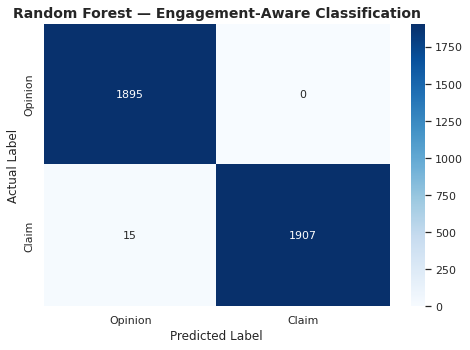

In [74]:
# ============================================================
# 10.9 CONFUSION MATRIX — RANDOM FOREST SCENARIO A
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred_a
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Opinion", "Claim"],
    yticklabels=["Opinion", "Claim"]
)

plt.title(
    "Random Forest — Engagement-Aware Classification",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [75]:
# ============================================================
# 10.10 CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred_a,
        target_names=["Opinion", "Claim"],
        digits=3
    )
)

              precision    recall  f1-score   support

     Opinion      0.992     1.000     0.996      1895
       Claim      1.000     0.992     0.996      1922

    accuracy                          0.996      3817
   macro avg      0.996     0.996     0.996      3817
weighted avg      0.996     0.996     0.996      3817



## 11. Cross-Validation and Hyperparameter Tuning

A single train-test split provides an estimate of model performance, but the result may depend on how the observations were divided.

To assess model stability, stratified cross-validation is used on the training data. Hyperparameter tuning is then performed for the Random Forest model using cross-validated F1-score as the optimization metric.

The test set remains untouched during this process and is used only for the final evaluation.

In [76]:
# ============================================================
# 11.1 STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    rf_model_a,
    X_train_a,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

display(
    cv_summary.style.format({
        "Mean": "{:.3f}",
        "Std": "{:.3f}"
    })
)

,Metric,Mean,Std
0,Accuracy,0.995,0.001
1,Precision,1.000,0.000
2,Recall,0.990,0.002
3,F1,0.995,0.001
4,ROC-AUC,0.997,0.001


### 11.2 Random Forest Hyperparameter Tuning

The Random Forest model is tuned using cross-validation.

The search focuses on tree depth, minimum samples required for a split or leaf, and the number of features considered at each split.

F1-score is used as the optimization metric because the project is a binary classification problem where both classes should be evaluated rather than relying solely on accuracy.

In [77]:
# ============================================================
# 11.2 RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_a),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

param_grid = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train_a,
    y_train
)

print("Best parameters:")
print(random_search.best_params_)

print(f"\nBest cross-validated F1: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.6min finished


Best parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'log2', 'classifier__max_depth': None}

Best cross-validated F1: 0.9950


In [82]:
# ============================================================
# 11.3 FINAL TUNED MODEL EVALUATION
# ============================================================

tuned_rf = random_search.best_estimator_

tuned_pred = tuned_rf.predict(X_test_a)
tuned_prob = tuned_rf.predict_proba(X_test_a)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred),
    "Recall": recall_score(y_test, tuned_pred),
    "F1": f1_score(y_test, tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_prob)
}

display(
    pd.DataFrame(
        tuned_metrics,
        index=["Tuned Random Forest — Scenario A"]
    ).T
)

,Tuned Random Forest — Scenario A
Accuracy,1.00
Precision,1.00
Recall,0.99
F1,1.00
ROC-AUC,1.00


In [83]:
# ============================================================
# 11.4 BEFORE VS AFTER TUNING
# ============================================================

tuning_comparison = pd.DataFrame([
    {
        "Model": "Random Forest — Before Tuning",
        **rf_a_metrics
    },
    {
        "Model": "Random Forest — After Tuning",
        **tuned_metrics
    }
])

display(
    tuning_comparison.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest — Before Tuning,0.996,1.000,0.992,0.996,0.999
1,Random Forest — After Tuning,0.996,1.000,0.992,0.996,0.998


#### Which variables contribute most to the model's predictions?

### 11.3 Feature Importance

Feature importance is examined to identify which predictors contribute most strongly to the Random Forest's classification decisions.

These results describe predictive importance within the model and should not be interpreted as causal effects.

In [118]:
# ============================================================
# 11.5 RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Numerical feature names
numeric_names = numeric_features_a


# Categorical feature names
verified_categories = (
    X_train_a["verified_status"]
    .dropna()
    .astype(str)
    .unique()
)

author_ban_categories = (
    X_train_a["author_ban_status"]
    .dropna()
    .astype(str)
    .unique()
)


categorical_names = (
    [f"verified_status_{category}" for category in verified_categories]
    +
    [f"author_ban_status_{category}" for category in author_ban_categories]
)


# Combine feature names
feature_names = numeric_names + categorical_names


# Extract Random Forest feature importances
importances = (
    rf_model_a
    .named_steps["classifier"]
    .feature_importances_
)


# Safety check
print(f"Number of feature names: {len(feature_names)}")
print(f"Number of importances:   {len(importances)}")


# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)


# Display top features
display(
    feature_importance.head(15).round(4)
)

Number of feature names: 11
Number of importances:   11


,Feature,Importance
0,video_view_count,0.33
1,video_like_count,0.24
2,video_share_count,0.17
4,video_download_count,0.16
3,video_comment_count,0.08
8,author_ban_status_active,0.01
5,video_duration_sec,0.00
9,author_ban_status_under review,0.00
10,author_ban_status_banned,0.00
7,verified_status_verified,0.00


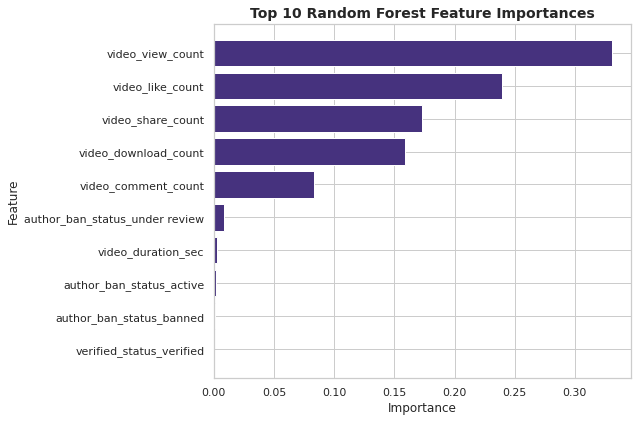

In [88]:
# ============================================================
# 11.6 TOP FEATURE IMPORTANCES
# ============================================================

top_features = (
    feature_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 Random Forest Feature Importances",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 12. Leakage and Robustness Assessment

The extremely high predictive performance observed in the engagement-aware model requires additional validation.

Engagement variables such as views, likes, shares, comments, and downloads may reflect information accumulated after a video is published. Therefore, their predictive contribution may not represent information available at the initial moderation stage.

To assess the robustness and practical usefulness of the model, performance is compared across feature sets with different levels of post-publication information.

In [89]:
# ============================================================
# 12.1 TARGET-LEVEL ENGAGEMENT ANALYSIS
# ============================================================

engagement_features = [
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count",
    "video_download_count"
]

target_engagement_summary = (
    model_data
    .groupby("claim_status")[engagement_features]
    .median()
    .T
)

display(
    target_engagement_summary.round(2)
)

claim_status,claim,opinion
video_view_count,501555.00,4953.00
video_like_count,123649.00,823.00
video_share_count,17997.50,121.00
video_comment_count,286.00,1.00
video_download_count,1139.50,7.00


In [90]:
# ============================================================
# 12.2 ENGAGEMENT RATE FEATURES
# ============================================================

model_data["like_rate"] = (
    model_data["video_like_count"] /
    model_data["video_view_count"].replace(0, np.nan)
)

model_data["share_rate"] = (
    model_data["video_share_count"] /
    model_data["video_view_count"].replace(0, np.nan)
)

model_data["comment_rate"] = (
    model_data["video_comment_count"] /
    model_data["video_view_count"].replace(0, np.nan)
)

model_data["download_rate"] = (
    model_data["video_download_count"] /
    model_data["video_view_count"].replace(0, np.nan)
)

print("Engagement-rate features created.")

display(
    model_data[
        [
            "like_rate",
            "share_rate",
            "comment_rate",
            "download_rate"
        ]
    ].describe().T
)

Engagement-rate features created.


,count,mean,std,min,25%,50%,75%,max
like_rate,19084.00,0.28,0.17,0.00,0.13,0.26,0.40,0.67
share_rate,19084.00,0.05,0.05,0.00,0.01,0.04,0.08,0.27
comment_rate,19084.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01
download_rate,19084.00,0.00,0.00,0.00,0.00,0.00,0.01,0.02


### 12.3 Deployment-Oriented Model Comparison

The engagement-aware model benefits from variables that may accumulate after publication.

A more conservative model uses only metadata that is potentially available without relying on accumulated engagement.

Comparing these scenarios helps distinguish predictive performance from practical deployment feasibility.

In [91]:
# ============================================================
# 12.3 SCENARIO COMPARISON
# ============================================================

scenario_comparison = model_results[
    ["Model", "Scenario", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].copy()

display(
    scenario_comparison.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)

,Model,Scenario,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Engagement-Aware,0.994,1.000,0.988,0.994,0.997
1,Random Forest,Engagement-Aware,0.996,1.000,0.992,0.996,0.999
2,Logistic Regression,Moderation-Time,0.615,0.824,0.299,0.439,0.641
3,Random Forest,Moderation-Time,0.609,0.750,0.336,0.464,0.637


### 12.4 Robustness Interpretation

The engagement-aware models achieve exceptionally high predictive performance, with the Random Forest reaching an F1-score of 0.996 and ROC-AUC of 0.997.

However, the median engagement levels differ substantially between claims and opinions. Claim-labeled videos have considerably higher views, likes, shares, comments, and downloads than opinion-labeled videos.

When engagement variables are removed, model performance declines substantially. The best moderation-oriented model achieves an F1-score of only 0.464 and ROC-AUC of 0.637.

These results indicate that post-publication engagement signals account for a large proportion of the predictive performance. Therefore, the engagement-aware results should not be interpreted as evidence that the model can reliably identify claims at the initial moderation stage.

The findings instead demonstrate an important distinction between:

1. **Predictive performance using accumulated engagement signals**, and
2. **Deployment-oriented performance using information available before substantial engagement occurs.**

This robustness analysis strengthens the interpretation of the model by showing that the exceptionally high performance is highly dependent on engagement-related variables.

## 13. Natural Language Processing

The video transcription text is analyzed to determine whether linguistic information can distinguish claims from opinions.

A TF-IDF representation is used to convert the transcription into numerical features. Both unigram and bigram features are considered so that the model can capture individual terms as well as short phrases.

A Logistic Regression classifier is then trained on the text representation.

In [92]:
# ============================================================
# 13.1 TEXT DATA QUALITY ASSESSMENT
# ============================================================

text_data = model_data["video_transcription_text"].fillna("").astype(str)

text_length = text_data.str.len()

text_summary = pd.DataFrame({
    "Metric": [
        "Total observations",
        "Empty transcriptions",
        "Non-empty transcriptions",
        "Mean characters",
        "Median characters",
        "Maximum characters"
    ],
    "Value": [
        len(text_data),
        (text_data.str.strip() == "").sum(),
        (text_data.str.strip() != "").sum(),
        text_length.mean(),
        text_length.median(),
        text_length.max()
    ]
})

display(text_summary)

,Metric,Value
0,Total observations,19084.00
1,Empty transcriptions,0.00
2,Non-empty transcriptions,19084.00
3,Mean characters,89.09
4,Median characters,87.00
5,Maximum characters,182.00


In [93]:
# ============================================================
# 13.2 TEXT AVAILABILITY BY TARGET CLASS
# ============================================================

text_availability = (
    model_data
    .assign(
        has_text=model_data["video_transcription_text"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )
    .groupby("claim_status")["has_text"]
    .agg(
        Videos="count",
        With_Text="sum"
    )
)

text_availability["Text_Availability_%"] = (
    text_availability["With_Text"] /
    text_availability["Videos"] * 100
)

display(
    text_availability.round(2)
)

,Videos,With_Text,Text_Availability_%
claim_status,,,
claim,9608,9608,100.00
opinion,9476,9476,100.00


In [94]:
# ============================================================
# 13.3 TEXT TRAIN / TEST SPLIT
# ============================================================

X_text = (
    model_data["video_transcription_text"]
    .fillna("")
    .astype(str)
)

X_text_train = X_text.loc[X_train_a.index]
X_text_test = X_text.loc[X_test_a.index]

y_text_train = y.loc[X_train_a.index]
y_text_test = y.loc[X_test_a.index]

print(f"Training text observations: {len(X_text_train):,}")
print(f"Testing text observations : {len(X_text_test):,}")

Training text observations: 15,267
Testing text observations : 3,817


### 13.4 TF-IDF Text Classification

TF-IDF assigns greater importance to terms that are frequent within a document but relatively uncommon across the corpus.

Unigrams and bigrams are included to capture both individual terms and short phrases that may contain useful signals for distinguishing claims from opinions.

The vectorizer and classifier are placed inside a single pipeline to prevent information from the test set influencing the training process.

In [95]:
# ============================================================
# 13.4 TF-IDF + LOGISTIC REGRESSION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            max_features=20000,
            strip_accents="unicode"
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

tfidf_model.fit(
    X_text_train,
    y_text_train
)

text_pred = tfidf_model.predict(X_text_test)
text_prob = tfidf_model.predict_proba(X_text_test)[:, 1]

text_metrics = {
    "Accuracy": accuracy_score(y_text_test, text_pred),
    "Precision": precision_score(y_text_test, text_pred),
    "Recall": recall_score(y_text_test, text_pred),
    "F1": f1_score(y_text_test, text_pred),
    "ROC-AUC": roc_auc_score(y_text_test, text_prob)
}

display(
    pd.DataFrame(
        text_metrics,
        index=["TF-IDF + Logistic Regression"]
    ).T
)

,TF-IDF + Logistic Regression
Accuracy,1.00
Precision,1.00
Recall,1.00
F1,1.00
ROC-AUC,1.00


In [96]:
# ============================================================
# 13.5A — REBUILD SCENARIO B DATA CORRECTLY
# ============================================================

scenario_b_features = [
    "video_duration_sec",
    "verified_status",
    "author_ban_status"
]

# Check that all required columns exist
missing_b = [
    col for col in scenario_b_features
    if col not in model_data.columns
]

if missing_b:
    raise KeyError(
        f"Missing Scenario B columns: {missing_b}"
    )

X_b = model_data[scenario_b_features].copy()
y_b = model_data["target"].copy()

print("Scenario B features:")
print(X_b.columns.tolist())

print(f"\nX_b shape: {X_b.shape}")
print(f"y_b shape: {y_b.shape}")

Scenario B features:
['video_duration_sec', 'verified_status', 'author_ban_status']

X_b shape: (19084, 3)
y_b shape: (19084,)


In [97]:
# ============================================================
# 13.5B — SCENARIO B TRAIN / TEST SPLIT
# ============================================================

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b,
    y_b,
    test_size=0.20,
    random_state=42,
    stratify=y_b
)

print(f"Training observations: {len(X_train_b):,}")
print(f"Testing observations : {len(X_test_b):,}")

Training observations: 15,267
Testing observations : 3,817


In [98]:
# # ============================================================
# 13.5C — SCENARIO B PREPROCESSOR
# ============================================================

numeric_features_b = [
    "video_duration_sec"
]

categorical_features_b = [
    "verified_status",
    "author_ban_status"
]

numeric_transformer_b = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_b = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor_b = ColumnTransformer([
    (
        "numeric",
        numeric_transformer_b,
        numeric_features_b
    ),
    (
        "categorical",
        categorical_transformer_b,
        categorical_features_b
    )
])

print("Scenario B preprocessor rebuilt successfully.")

Scenario B preprocessor rebuilt successfully.


In [99]:
# ============================================================
# 13.5D — RANDOM FOREST — MODERATION-TIME
# ============================================================

rf_model_b = Pipeline([
    (
        "preprocessor",
        preprocessor_b
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

rf_model_b.fit(
    X_train_b,
    y_train_b
)

rf_b_pred_check = rf_model_b.predict(
    X_test_b
)

rf_b_prob_check = (
    rf_model_b
    .predict_proba(X_test_b)[:, 1]
)

rf_b_metrics = {
    "Accuracy": accuracy_score(
        y_test_b,
        rf_b_pred_check
    ),
    "Precision": precision_score(
        y_test_b,
        rf_b_pred_check
    ),
    "Recall": recall_score(
        y_test_b,
        rf_b_pred_check
    ),
    "F1": f1_score(
        y_test_b,
        rf_b_pred_check
    ),
    "ROC-AUC": roc_auc_score(
        y_test_b,
        rf_b_prob_check
    )
}

print(
    "Moderation-Time Random Forest fitted successfully."
)

display(
    pd.DataFrame(
        rf_b_metrics,
        index=["Random Forest — Moderation-Time"]
    ).T
)

Moderation-Time Random Forest fitted successfully.


,Random Forest — Moderation-Time
Accuracy,0.61
Precision,0.75
Recall,0.34
F1,0.46
ROC-AUC,0.64


In [100]:
# ============================================================
# 13.5E — TEXT VS TABULAR MODEL COMPARISON
# ============================================================

text_comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Feature Type": "Transcription Text",
        **text_metrics
    },
    {
        "Model": "Random Forest",
        "Feature Type": "Engagement + Metadata",
        **rf_a_metrics
    },
    {
        "Model": "Random Forest",
        "Feature Type": "Moderation-Oriented Metadata",
        **rf_b_metrics
    }
])

display(
    text_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Feature Type,Accuracy,Precision,Recall,F1,ROC-AUC
0,TF-IDF + Logistic Regression,Transcription Text,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,Engagement + Metadata,0.9961,1.0000,0.9922,0.9961,0.9985
2,Random Forest,Moderation-Oriented Metadata,0.6094,0.7503,0.3361,0.4642,0.6371


### 13.6 Text Model Interpretation

The transcription-based model provides an independent assessment of whether linguistic information contains predictive signals for distinguishing claims from opinions.

Its performance is compared with the engagement-aware and moderation-oriented tabular models.

This comparison helps determine whether the classification task can be supported by the content itself rather than relying primarily on accumulated engagement behavior.

In [101]:
# ============================================================
# 13.6 DUPLICATE TEXT CHECK
# ============================================================

text_clean = (
    model_data["video_transcription_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

duplicate_count = text_clean.duplicated().sum()

print(f"Total observations: {len(text_clean):,}")
print(f"Duplicate transcription rows: {duplicate_count:,}")
print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(text_clean) * 100:.2f}%"
)

Total observations: 19,084
Duplicate transcription rows: 72
Duplicate percentage: 0.38%


In [102]:
# ============================================================
# 13.7 TEXT CONSISTENCY WITH TARGET
# ============================================================

text_target_groups = (
    model_data
    .groupby("video_transcription_text")["claim_status"]
    .nunique()
)

conflicting_texts = (
    text_target_groups[text_target_groups > 1]
)

print(
    f"Unique transcriptions with conflicting labels: "
    f"{len(conflicting_texts):,}"
)

Unique transcriptions with conflicting labels: 0


In [103]:
# ============================================================
# 13.8 TOP TF-IDF FEATURES
# ============================================================

tfidf_vectorizer = tfidf_model.named_steps["tfidf"]
tfidf_classifier = tfidf_model.named_steps["classifier"]

# Compatible with older scikit-learn versions
feature_names = tfidf_vectorizer.get_feature_names()

coefficients = tfidf_classifier.coef_[0]

tfidf_features = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Positive coefficients → Claim
positive_features = (
    tfidf_features
    .sort_values("Coefficient", ascending=False)
    .head(20)
)

# Negative coefficients → Opinion
negative_features = (
    tfidf_features
    .sort_values("Coefficient", ascending=True)
    .head(20)
)

print("Top features associated with CLAIM:")
display(positive_features)

print("\nTop features associated with OPINION:")
display(negative_features)

Top features associated with CLAIM:


,Feature,Coefficient
2734,read,7.78
1892,learned,7.00
993,discovered,6.85
3007,someone,6.64
1338,friend,6.32
810,colleague,5.74
2021,media,5.43
789,claim that,5.17
788,claim,5.17
2347,on,4.95



Top features associated with OPINION:


,Feature,Coefficient
2155,my,-10.31
1768,is that,-9.28
1730,is,-6.75
2453,our,-5.19
2158,my family,-4.28
1198,family,-4.28
2160,my friends,-4.26
1349,friends,-4.18
2852,say,-3.85
2853,say that,-3.85


In [104]:
# ============================================================
# 13.9 SAMPLE TRANSCRIPTIONS BY CLASS
# ============================================================

print("SAMPLE CLAIM TRANSCRIPTIONS")
display(
    model_data.loc[
        model_data["claim_status"] == "claim",
        ["claim_status", "video_transcription_text"]
    ].sample(
        min(10, (model_data["claim_status"] == "claim").sum()),
        random_state=42
    )
)

print("\nSAMPLE OPINION TRANSCRIPTIONS")
display(
    model_data.loc[
        model_data["claim_status"] == "opinion",
        ["claim_status", "video_transcription_text"]
    ].sample(
        min(10, (model_data["claim_status"] == "opinion").sum()),
        random_state=42
    )
)

SAMPLE CLAIM TRANSCRIPTIONS


,claim_status,video_transcription_text
2114,claim,a friend learned from the news that it takes ...
5107,claim,i learned from the media that the eye of an o...
8151,claim,i discovered a story mentioning that a dog’s s...
2880,claim,a friend read in the news that china is the w...
7991,claim,i read a story mentioning that more people spe...
2304,claim,a friend read online that antarctica is the o...
8387,claim,a colleague located an article claiming that 1...
1483,claim,a colleague claimed the media revealed bathwat...
1897,claim,a friend learned on social media a claim that...
5138,claim,i learned from the media a claim that the chi...



SAMPLE OPINION TRANSCRIPTIONS


,claim_status,video_transcription_text
13201,opinion,our reasoning is that neptune’s winds are the ...
11881,opinion,"my sentiment is that shanghai, china has the w..."
15746,opinion,my family's hypothesis is that antarctica is t...
10575,opinion,my friends believe that ketchup leaves the bot...
14455,opinion,my friends' belief is that the longest commerc...
18879,opinion,my colleagues are convinced that violin bows ...
14164,opinion,my friends' sentiment is that the longest poss...
10954,opinion,my colleagues believe that more people speak e...
14847,opinion,my family's opinion is that the concorde was t...
17319,opinion,my friends say that dogs can understand up to ...


### 13.7 NLP Model Diagnostic and Dataset-Design Assessment

The TF-IDF classifier achieved perfect classification performance on the held-out test set. However, inspection of the transcription samples indicates that the dataset contains highly distinctive linguistic patterns associated with the target classes.

Claim-labeled examples frequently contain explicit claim-related or information-source expressions, whereas opinion-labeled examples frequently contain expressions associated with beliefs, sentiment, hypotheses, or personal judgment.

This indicates that the NLP model may be exploiting systematic lexical and template-level differences in the dataset rather than learning generalizable semantic distinctions between claims and opinions.

Therefore, the perfect NLP performance is treated as a dataset-specific result rather than evidence of production-ready language classification.

This finding is important for model evaluation because exceptionally high performance can result from label-correlated language patterns in synthetic or highly structured datasets.

### 13.8 Lexical-Robustness Test

Because the transcription data contain explicit class-associated expressions, a lexical-robustness test is performed.

Common label-indicative terms and phrases are removed before TF-IDF modeling. The resulting performance is compared with the original text model to assess how dependent classification is on explicit lexical cues.

In [105]:
# ============================================================
# 13.8 LEXICAL-ROBUSTNESS TEXT PREPROCESSING
# ============================================================

import re

def remove_label_cues(text):
    text = str(text).lower()

    label_cues = [
        "claim",
        "claims",
        "claimed",
        "opinion",
        "opinions",
        "believe",
        "believes",
        "belief",
        "sentiment",
        "hypothesis",
        "hypotheses",
        "reasoning",
        "convinced"
    ]

    for cue in label_cues:
        text = re.sub(
            r"\b" + re.escape(cue) + r"\b",
            "",
            text
        )

    return text


X_text_train_robust = X_text_train.apply(remove_label_cues)
X_text_test_robust = X_text_test.apply(remove_label_cues)

print("Lexical cue removal completed.")

Lexical cue removal completed.


In [106]:
# ============================================================
# 13.9 ROBUST TF-IDF MODEL
# ============================================================

tfidf_robust_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95,
            sublinear_tf=True,
            max_features=20000,
            strip_accents="unicode"
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

tfidf_robust_model.fit(
    X_text_train_robust,
    y_text_train
)

robust_pred = tfidf_robust_model.predict(
    X_text_test_robust
)

robust_prob = tfidf_robust_model.predict_proba(
    X_text_test_robust
)[:, 1]

robust_text_metrics = {
    "Accuracy": accuracy_score(
        y_text_test,
        robust_pred
    ),
    "Precision": precision_score(
        y_text_test,
        robust_pred
    ),
    "Recall": recall_score(
        y_text_test,
        robust_pred
    ),
    "F1": f1_score(
        y_text_test,
        robust_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_text_test,
        robust_prob
    )
}

display(
    pd.DataFrame(
        robust_text_metrics,
        index=["Robust TF-IDF + Logistic Regression"]
    ).T
)

,Robust TF-IDF + Logistic Regression
Accuracy,1.00
Precision,1.00
Recall,1.00
F1,1.00
ROC-AUC,1.00


In [107]:
# ============================================================
# 13.10 NLP ROBUSTNESS COMPARISON
# ============================================================

nlp_robustness = pd.DataFrame([
    {
        "Model": "Original TF-IDF",
        **text_metrics
    },
    {
        "Model": "Lexical-Robustness TF-IDF",
        **robust_text_metrics
    }
])

display(
    nlp_robustness.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Original TF-IDF,1.0000,1.0000,1.0000,1.0000,1.0000
1,Lexical-Robustness TF-IDF,1.0000,1.0000,1.0000,1.0000,1.0000


### 13.11 Dataset-Level Text Pattern Analysis

The NLP model retains perfect performance after removal of a predefined set of explicit label-related terms.

This suggests that additional lexical, syntactic, or template-level patterns may distinguish the two classes.

The next analysis examines common n-grams separately within each class to identify systematic language patterns that may explain the unusually strong NLP performance.

In [108]:
# ============================================================
# 13.11 CLASS-SPECIFIC TEXT PATTERN ANALYSIS
# ============================================================

from collections import Counter
import re

def tokenize_text(text):
    return re.findall(r"\b[a-zA-Z]+\b", str(text).lower())


claim_text = model_data.loc[
    model_data["claim_status"] == "claim",
    "video_transcription_text"
].apply(tokenize_text)

opinion_text = model_data.loc[
    model_data["claim_status"] == "opinion",
    "video_transcription_text"
].apply(tokenize_text)


def get_ngrams(token_lists, n=2):
    counter = Counter()

    for tokens in token_lists:
        counter.update(
            zip(*[tokens[i:] for i in range(n)])
        )

    return counter


claim_bigrams = get_ngrams(claim_text, n=2)
opinion_bigrams = get_ngrams(opinion_text, n=2)

claim_top = pd.DataFrame(
    claim_bigrams.most_common(20),
    columns=["Bigram", "Count"]
)

opinion_top = pd.DataFrame(
    opinion_bigrams.most_common(20),
    columns=["Bigram", "Count"]
)

claim_top["Bigram"] = claim_top["Bigram"].apply(
    lambda x: " ".join(x)
)

opinion_top["Bigram"] = opinion_top["Bigram"].apply(
    lambda x: " ".join(x)
)

print("Most common bigrams in CLAIM transcriptions:")
display(claim_top)

print("\nMost common bigrams in OPINION transcriptions:")
display(opinion_top)

Most common bigrams in CLAIM transcriptions:


,Bigram,Count
0,claim that,3501
1,a claim,3461
2,in the,2609
3,that the,2554
4,a friend,2490
5,a colleague,2419
6,the media,1780
7,the news,1551
8,read in,1463
9,from the,1129



Most common bigrams in OPINION transcriptions:


,Bigram,Count
0,is that,5822
1,that the,2547
2,my friends,2155
3,my colleagues,1958
4,my family,1936
5,in the,1323
6,family s,1160
7,willing to,1136
8,the world,1007
9,view is,992


In [109]:
# ============================================================
# 13.12 VOCABULARY OVERLAP
# ============================================================

claim_vocab = set(
    word
    for tokens in claim_text
    for word in tokens
)

opinion_vocab = set(
    word
    for tokens in opinion_text
    for word in tokens
)

shared_vocab = claim_vocab.intersection(opinion_vocab)
all_vocab = claim_vocab.union(opinion_vocab)

vocabulary_overlap = (
    len(shared_vocab) /
    len(all_vocab) * 100
)

print(f"Claim vocabulary size   : {len(claim_vocab):,}")
print(f"Opinion vocabulary size : {len(opinion_vocab):,}")
print(f"Shared vocabulary       : {len(shared_vocab):,}")
print(f"Vocabulary overlap      : {vocabulary_overlap:.2f}%")

Claim vocabulary size   : 1,196
Opinion vocabulary size : 1,197
Shared vocabulary       : 1,168
Vocabulary overlap      : 95.35%


In [110]:
# ============================================================
# 13.13 CLASS-SPECIFIC WORD ASSOCIATION
# ============================================================

claim_word_counts = Counter(
    word
    for tokens in claim_text
    for word in tokens
)

opinion_word_counts = Counter(
    word
    for tokens in opinion_text
    for word in tokens
)

claim_total = sum(claim_word_counts.values())
opinion_total = sum(opinion_word_counts.values())

vocab = set(claim_word_counts) | set(opinion_word_counts)

word_association = []

for word in vocab:

    claim_rate = (
        claim_word_counts[word] / claim_total
    )

    opinion_rate = (
        opinion_word_counts[word] / opinion_total
    )

    ratio = (
        claim_rate /
        (opinion_rate + 1e-10)
    )

    word_association.append({
        "Word": word,
        "Claim_Rate": claim_rate,
        "Opinion_Rate": opinion_rate,
        "Claim_to_Opinion_Ratio": ratio
    })

word_association = pd.DataFrame(
    word_association
)

claim_specific_words = (
    word_association[
        word_association["Claim_Rate"] > 0
    ]
    .sort_values(
        "Claim_to_Opinion_Ratio",
        ascending=False
    )
    .head(20)
)

opinion_specific_words = (
    word_association[
        word_association["Opinion_Rate"] > 0
    ]
    .sort_values(
        "Claim_to_Opinion_Ratio",
        ascending=True
    )
    .head(20)
)

print("Words disproportionately associated with CLAIM:")
display(claim_specific_words)

print("\nWords disproportionately associated with OPINION:")
display(opinion_specific_words)

Words disproportionately associated with CLAIM:


,Word,Claim_Rate,Opinion_Rate,Claim_to_Opinion_Ratio
659,claim,0.02,0.00,213873362.05
1090,read,0.02,0.00,201716607.10
967,learned,0.02,0.00,180213201.38
757,media,0.02,0.00,152234338.25
750,friend,0.02,0.00,152112159.81
558,colleague,0.01,0.00,147774825.13
243,news,0.01,0.00,94749381.47
536,online,0.00,0.00,45389291.06
907,website,0.00,0.00,45083844.96
989,forum,0.00,0.00,44961666.51



Words disproportionately associated with OPINION:


,Word,Claim_Rate,Opinion_Rate,Claim_to_Opinion_Ratio
724,impression,0.00,0.00,0.00
1044,think,0.00,0.00,0.00
1012,hypothesis,0.00,0.00,0.00
998,colleagues,0.00,0.01,0.00
869,understanding,0.00,0.00,0.00
819,feeling,0.00,0.00,0.00
720,tell,0.00,0.00,0.00
625,thinking,0.00,0.00,0.00
616,reasoning,0.00,0.00,0.00
614,family,0.00,0.01,0.00


## 14. Final Model Evaluation

The evaluated models represent three different information settings:

1. **Engagement-Aware Models** — use post-publication engagement and metadata.
2. **Moderation-Time Models** — use metadata that is less dependent on accumulated engagement.
3. **NLP Model** — uses video transcription text.

The models are compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

F1-score is emphasized because it balances precision and recall and provides a more informative measure when evaluating classification performance across both classes.

In [111]:
# ============================================================
# 14.1A FIT MODERATION-TIME MODELS
# ============================================================

# Fit Logistic Regression — Moderation-Time
logistic_model_b.fit(
    X_train_b,
    y_train
)

# Fit Random Forest — Moderation-Time
rf_model_b.fit(
    X_train_b,
    y_train
)

print("Moderation-time models fitted successfully.")

Moderation-time models fitted successfully.


In [112]:
# ============================================================
# 14.1 FINAL MODEL PERFORMANCE COMPARISON
# ============================================================

# Logistic Regression — Moderation-Time
logistic_b_pred_final = logistic_model_b.predict(X_test_b)
logistic_b_prob_final = logistic_model_b.predict_proba(X_test_b)[:, 1]

logistic_b_metrics_final = {
    "Accuracy": accuracy_score(y_test, logistic_b_pred_final),
    "Precision": precision_score(y_test, logistic_b_pred_final),
    "Recall": recall_score(y_test, logistic_b_pred_final),
    "F1": f1_score(y_test, logistic_b_pred_final),
    "ROC-AUC": roc_auc_score(y_test, logistic_b_prob_final)
}

# Random Forest — Moderation-Time
rf_b_pred_final = rf_model_b.predict(X_test_b)
rf_b_prob_final = rf_model_b.predict_proba(X_test_b)[:, 1]

rf_b_metrics_final = {
    "Accuracy": accuracy_score(y_test, rf_b_pred_final),
    "Precision": precision_score(y_test, rf_b_pred_final),
    "Recall": recall_score(y_test, rf_b_pred_final),
    "F1": f1_score(y_test, rf_b_pred_final),
    "ROC-AUC": roc_auc_score(y_test, rf_b_prob_final)
}

# Final model comparison
final_model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Feature Setting": "Engagement-Aware",
        **logistic_a_metrics
    },
    {
        "Model": "Random Forest",
        "Feature Setting": "Engagement-Aware",
        **rf_a_metrics
    },
    {
        "Model": "Logistic Regression",
        "Feature Setting": "Moderation-Time",
        **logistic_b_metrics_final
    },
    {
        "Model": "Random Forest",
        "Feature Setting": "Moderation-Time",
        **rf_b_metrics_final
    },
    {
        "Model": "TF-IDF + Logistic Regression",
        "Feature Setting": "Transcription Text",
        **text_metrics
    },
    {
        "Model": "Lexical-Robustness TF-IDF",
        "Feature Setting": "Transcription Text",
        **robust_text_metrics
    }
])

display(
    final_model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Feature Setting,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Engagement-Aware,0.9940,1.0000,0.9880,0.9940,0.9973
1,Random Forest,Engagement-Aware,0.9961,1.0000,0.9922,0.9961,0.9985
2,Logistic Regression,Moderation-Time,0.6149,0.8238,0.2992,0.4389,0.6406
3,Random Forest,Moderation-Time,0.6094,0.7503,0.3361,0.4642,0.6371
4,TF-IDF + Logistic Regression,Transcription Text,1.0000,1.0000,1.0000,1.0000,1.0000
5,Lexical-Robustness TF-IDF,Transcription Text,1.0000,1.0000,1.0000,1.0000,1.0000


### 14.2 Model Selection

Model selection is based not only on predictive performance but also on the type and timing of information required by each model.

The engagement-aware models achieve substantially stronger predictive performance than the moderation-time models. However, their reliance on accumulated engagement signals limits their interpretation as models for initial moderation.

The transcription-based models achieve perfect test-set performance in this dataset. Because this result remains unchanged after the selected lexical-cue robustness test, it is treated as a dataset-specific finding requiring external validation rather than as evidence of production-ready performance.

Therefore, model performance is interpreted together with feature availability, robustness, and practical deployment considerations.

## 15. Model Explainability

Model explainability is used to identify which variables contribute most strongly to the Random Forest's predictions.

Feature importance provides a global view of the relative contribution of the predictors and helps translate model outputs into interpretable analytical insights.

Because the engagement-aware Random Forest achieved the strongest performance among the tabular models, its feature importance is examined in greater detail.

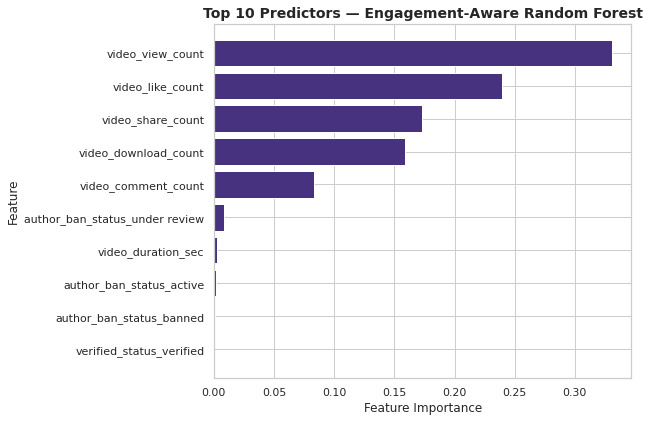

In [113]:
# ============================================================
# 15.1 RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

top_n = 10

top_importance = (
    feature_importance
    .head(top_n)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_importance["Feature"],
    top_importance["Importance"]
)

plt.title(
    "Top 10 Predictors — Engagement-Aware Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [114]:
# ============================================================
# 15.2 TOP PREDICTORS
# ============================================================

top_predictors = (
    feature_importance
    .head(10)
    .copy()
)

top_predictors["Importance_%"] = (
    top_predictors["Importance"] * 100
)

display(
    top_predictors[
        ["Feature", "Importance_%"]
    ].round(2)
)

,Feature,Importance_%
0,video_view_count,33.05
1,video_like_count,23.95
2,video_share_count,17.32
4,video_download_count,15.88
3,video_comment_count,8.31
8,author_ban_status_under review,0.87
5,video_duration_sec,0.25
9,author_ban_status_active,0.22
10,author_ban_status_banned,0.12
7,verified_status_verified,0.02


### 15.3 Feature Importance Interpretation

The feature-importance analysis shows that engagement-related variables account for the majority of the Random Forest's predictive signal.

Views, likes, shares, downloads, and comments are substantially more influential than video duration and verification status.

This finding is consistent with the robustness analysis: the engagement-aware model performs exceptionally well, whereas removing engagement variables causes a substantial reduction in predictive performance.

However, feature importance represents predictive association rather than causation. High importance does not imply that engagement causes a video to be classified as a claim.

The results therefore support the use of engagement variables as predictive signals, while also reinforcing the need to consider their availability and timing when designing a real-world moderation system.

## 16. Business & Moderation Insights

The analysis provides several practical insights for content-moderation workflows.

The results indicate that engagement signals are highly predictive of the target classification, while moderation-time metadata alone provides substantially weaker predictive performance.

The transcription-based NLP model achieves perfect performance on the available test set, but this result is treated as dataset-specific because the transcription data contain strong class-associated linguistic patterns.

Based on these findings, the model results are interpreted as decision-support signals rather than as evidence for fully automated moderation decisions.

### 16.1 Key Findings

**1. Engagement is the strongest predictive signal**

Views, likes, shares, comments, and downloads account for most of the predictive power in the engagement-aware Random Forest.

**2. Timing of information matters**

The engagement-aware Random Forest achieves an F1-score of 0.9961, while the moderation-time Random Forest achieves an F1-score of only 0.4642.

This indicates that predictive performance is strongly dependent on post-publication engagement information.

**3. Text contains highly discriminative information**

The TF-IDF model achieves an F1-score of 1.0000. The same performance is retained after removing a selected set of explicit lexical cues.

This suggests that the dataset contains additional systematic linguistic patterns that strongly distinguish the two target classes.

**4. Perfect NLP performance requires external validation**

The NLP result should not be interpreted as evidence of production-ready performance. Evaluation on independently collected, naturally occurring content would be required to establish generalization.

**5. Predictive association is not causation**

Feature importance identifies variables that help the model distinguish between classes. It does not establish that engagement causes a video to be classified as a claim or opinion.

### 16.2 Recommended Moderation Workflow

Based on the analysis, a practical moderation-support workflow could use a staged approach:

**Stage 1 — Initial Screening**

Use information available at or near publication, including video metadata and transcription-based signals, to identify content requiring further review.

**Stage 2 — Risk Prioritization**

Where post-publication engagement becomes available, engagement metrics can be incorporated as additional prioritization signals.

**Stage 3 — Human Review**

High-risk or uncertain cases should be routed to human moderators rather than automatically classified solely by the model.

**Stage 4 — Continuous Validation**

Model performance should be monitored on newly collected and independently labeled content to detect changes in language, engagement behavior, and data distribution.

### 16.3 Limitations

Several limitations should be considered when interpreting the results:

- The dataset contains highly structured transcription patterns that may make the NLP classification task substantially easier than real-world moderation.
- Engagement variables may represent information accumulated after publication and therefore may not be available during initial moderation.
- The observed performance comes from a single dataset and fixed train/test evaluation.
- Perfect NLP performance on this dataset does not guarantee generalization to naturally occurring social-media content.
- Feature importance indicates predictive association rather than causal relationships.
- External validation on an independently collected dataset would be necessary before deployment.

### 16.4 Recommended Next Steps

For future development, the following steps would strengthen the modeling pipeline:

1. Validate the models on an independently collected dataset.
2. Evaluate performance using temporally separated data to test generalization over time.
3. Investigate whether the observed linguistic patterns remain present in naturally occurring transcription data.
4. Establish a clear definition of which variables are available at each stage of moderation.
5. Evaluate probability calibration and decision thresholds before operational deployment.
6. Monitor model performance and data drift after deployment.
7. Maintain human oversight for high-impact moderation decisions.

## 17. Final Visualizations

The final visualizations summarize the most important findings from the exploratory analysis and modeling stages.

Only visuals that directly support the project's conclusions are retained to maintain a concise and decision-oriented presentation.

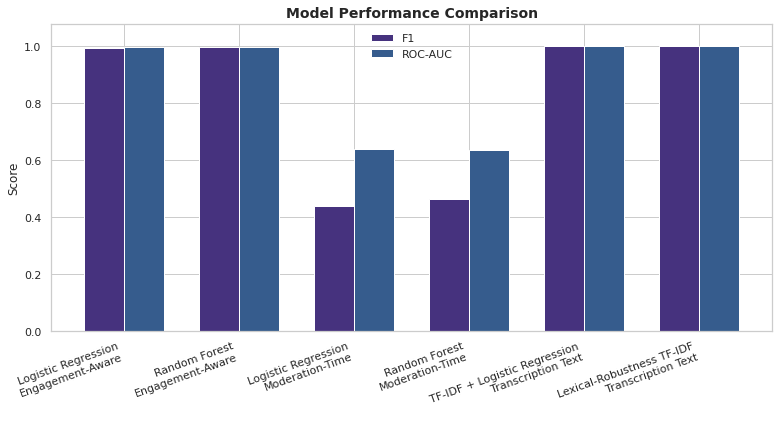

In [115]:
# ============================================================
# 17.1 MODEL PERFORMANCE COMPARISON
# ============================================================

performance_plot = final_model_comparison.copy()

plt.figure(figsize=(11, 6))

x = np.arange(len(performance_plot))
width = 0.35

plt.bar(
    x - width / 2,
    performance_plot["F1"],
    width,
    label="F1"
)

plt.bar(
    x + width / 2,
    performance_plot["ROC-AUC"],
    width,
    label="ROC-AUC"
)

plt.xticks(
    x,
    performance_plot["Model"] + "\n" +
    performance_plot["Feature Setting"],
    rotation=20,
    ha="right"
)

plt.ylim(0, 1.08)

plt.ylabel("Score")
plt.title(
    "Model Performance Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.tight_layout()
plt.show()

### 17.2 Engagement Differences by Content Class

Engagement metrics show substantial differences between claim and opinion content.

Median values are used because engagement distributions are typically highly skewed and therefore median values provide a more robust representation of the typical observation.

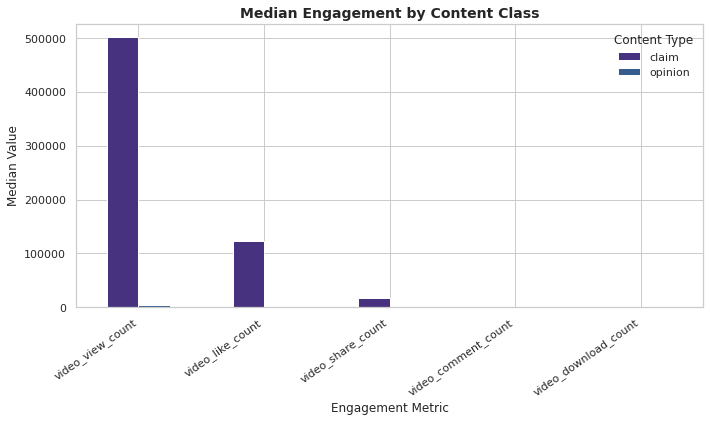

In [116]:
# ============================================================
# 17.2 MEDIAN ENGAGEMENT BY CONTENT CLASS
# ============================================================

engagement_medians = (
    model_data
    .groupby("claim_status")[engagement_features]
    .median()
)

engagement_medians.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Median Engagement by Content Class",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Engagement Metric")
plt.ylabel("Median Value")

plt.xticks(rotation=35, ha="right")

plt.legend(title="Content Type")

plt.tight_layout()
plt.show()

### 17.3 Engagement-Aware Random Forest Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly classified observations for the strongest tabular model.

It provides a more direct view of classification errors than aggregate performance metrics alone.

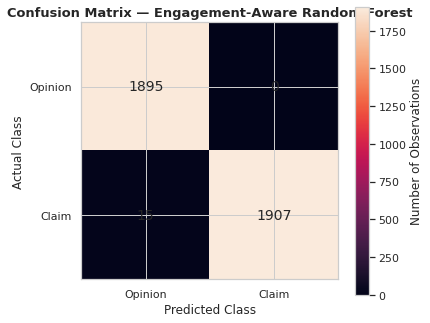

In [117]:
# ============================================================
# 17.3 CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

# Generate predictions from the engagement-aware Random Forest
rf_a_pred_final = rf_model_a.predict(X_test_a)

# Calculate confusion matrix
cm = confusion_matrix(
    y_test,
    rf_a_pred_final
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Confusion Matrix — Engagement-Aware Random Forest",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Opinion", "Claim"]
)

plt.yticks(
    [0, 1],
    ["Opinion", "Claim"]
)

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar(label="Number of Observations")

plt.tight_layout()
plt.show()

### 17.5 Visualization Summary

The final visualizations highlight three central findings:

- Engagement variables are substantially different between claim and opinion content.
- Engagement-aware models substantially outperform moderation-time models.
- The Random Forest achieves very strong tabular predictive performance, while its feature importance is dominated by engagement-related variables.

Together, these visuals support the project's central conclusion that predictive performance is strongly influenced by the information available to the model and by the structure of the transcription data.

# 18. Executive Summary

## Project Objective

The objective of this project was to investigate whether TikTok video content could be classified as **claim** or **opinion** using structured metadata, engagement signals, and video transcription text.

The analysis was designed to compare predictive performance under different information settings and to assess the practical implications of using these signals for content-moderation support.

## Key Findings

### 1. Engagement-aware models achieved very high predictive performance

The Engagement-Aware Random Forest achieved:

- **Accuracy:** 99.61%
- **Precision:** 100.00%
- **Recall:** 99.22%
- **F1-score:** 99.61%
- **ROC-AUC:** 99.74%

However, these results depend heavily on engagement variables such as views, likes, shares, comments, and downloads. These variables may accumulate after publication and therefore may not be available during initial moderation.

### 2. Moderation-time metadata provided substantially weaker predictive performance

When engagement variables were excluded, the Random Forest achieved an F1-score of **46.42%** and ROC-AUC of **63.71%**.

This substantial performance reduction demonstrates that the predictive strength of the engagement-aware model is strongly dependent on information that may not be available at the initial moderation stage.

### 3. Transcription text was highly predictive in this dataset

The TF-IDF + Logistic Regression model achieved:

- **Accuracy:** 100%
- **Precision:** 100%
- **Recall:** 100%
- **F1-score:** 100%
- **ROC-AUC:** 100%

The same performance remained after removing a selected set of explicit lexical cues.

This indicates that the transcription data contain highly systematic linguistic patterns associated with the target classes.

However, perfect performance on this dataset should not be interpreted as evidence of production readiness. Independent external validation would be required to determine whether these patterns generalize to naturally occurring content.

### 4. Feature importance highlighted engagement as the dominant tabular signal

The Random Forest feature-importance analysis identified engagement variables as the dominant predictive signals among the tabular features. Their importance was substantially greater than that of basic metadata variables such as video duration and verification status. These results represent predictive associations and should not be interpreted as causal relationships.

## Overall Conclusion

The analysis demonstrates that classification performance varies substantially depending on the information available to the model. The strongest predictive results were obtained from engagement-aware and transcription-based models. However, the engagement-aware results have practical timing limitations, while the perfect NLP performance requires additional validation because of the highly structured nature of the available transcription data.

Therefore, model selection should consider not only predictive performance but also feature availability, robustness, generalizability, and deployment conditions. The results support the potential use of machine-learning models as content-moderation decision-support tools, but independent validation and appropriate human oversight would be required before operational deployment.

## 18.1 Final Recommendations

Based on the complete analysis, the following recommendations are proposed:

1. **Use machine learning as a moderation-support system rather than an autonomous decision-maker.**

2. **Separate features by information availability.** Models intended for initial moderation should rely primarily on signals available at or near publication.

3. **Treat engagement metrics as contextual or prioritization signals** when they become available rather than relying on them for initial moderation decisions.

4. **Validate NLP performance externally.** The perfect transcription-based performance observed in this dataset requires testing on independently collected and naturally occurring content.

5. **Maintain human review for uncertain or high-impact cases.** Model predictions should assist moderators rather than replace human judgment.

6. **Monitor model performance over time** for changes in language, engagement behavior, and data distributions.

7. **Reassess model performance periodically** using newly labeled data to ensure that predictive relationships remain valid.

## 18.2 Final Takeaway

The key lesson from this analysis is that **high predictive performance must always be interpreted in the context of feature availability, dataset structure, and deployment conditions**.

Rather than selecting a model solely because it produces the highest test-set score, this project evaluates the relationship between predictive performance and practical usability.

This provides a more realistic framework for developing data-driven content-moderation systems.

# 19. Final Project Structure

The completed analysis follows an end-to-end data science workflow:

1. Business Problem & Project Objective
2. Data Loading and Initial Inspection
3. Data Cleaning and Quality Assessment
4. Exploratory Data Analysis
5. Target Variable Analysis
6. Feature Engineering
7. Target Encoding and Modeling Dataset
8. Scenario A — Engagement-Aware Modeling
9. Scenario B — Moderation-Time Modeling
10. Baseline and Machine-Learning Models
11. Model Evaluation
12. Leakage and Robustness Assessment
13. Natural Language Processing
14. Final Model Evaluation
15. Model Explainability
16. Business & Moderation Insights
17. Final Visualizations
18. Executive Summary and Recommendations

The analysis combines exploratory data analysis, supervised machine learning, natural language processing, robustness assessment, model explainability, and business interpretation to evaluate the feasibility of automated content-classification support.

## Final Conclusion

This project demonstrates an end-to-end approach to classifying TikTok content using structured metadata, engagement signals, and transcription text.

The analysis shows that model performance is highly dependent on the information supplied to the classifier. Engagement-aware models achieve very high predictive performance, while moderation-time metadata alone provides substantially weaker discrimination. Transcription-based NLP also achieves perfect performance on the available dataset, although this result requires independent validation before practical deployment.

The project therefore emphasizes not only predictive accuracy, but also feature availability, robustness, interpretability, generalizability, and deployment considerations.

The resulting framework provides a foundation for future development of human-in-the-loop content-moderation decision-support systems.